In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  OneHotEncoder, RobustScaler , PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score ,f1_score ,precision_score, recall_score
from sklearn.metrics import accuracy_score ,classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVR ,SVC
from sklearn.ensemble import RandomForestRegressor ,RandomForestClassifier
from sklearn.ensemble import VotingRegressor, VotingClassifier, GradientBoostingRegressor, GradientBoostingClassifier, StackingRegressor, StackingClassifier
from sklearn.model_selection import KFold


# Task 1 : Exploratory Data Analysis (EDA)

Load & Inspect dataset

In [4]:
url = "Fifa.csv"
df = pd.read_csv(url)
print("Dataset Shape: ",df.shape)
df.head()

Dataset Shape:  (19667, 9)


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


Display dataset information (data types, null values)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


Plot histogram of Value Per M$ distribution to understand player value spread

<Axes: >

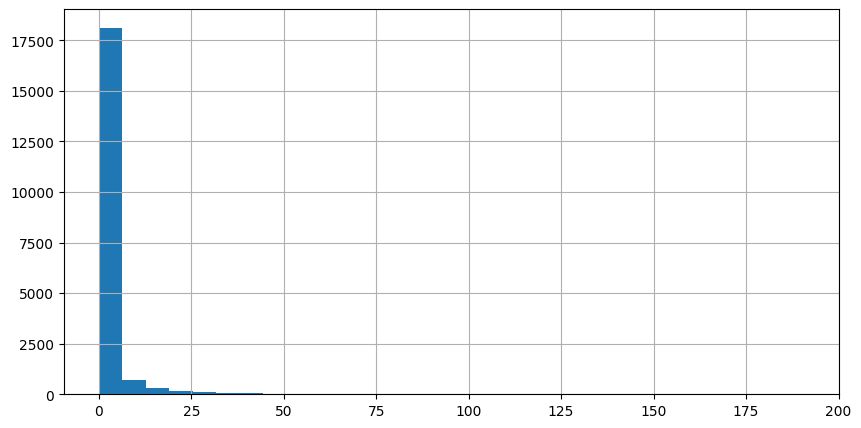

In [6]:
df['Value Per M$'].hist(bins=30,figsize=(10,5))

The distribution of 'Value Per M$' is highly right skewed

In [7]:
f"Skewness : {df["Value Per M$"].skew():.2f}"

'Skewness : 7.98'

Generate descriptive statistics summary of the dataset

In [8]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


The **standard deviation** of “Value Per M$” is significantly **higher** than the **mean**, indicating **high variability**

Get top 5 players with the highest Value Per M$

In [9]:
df.nlargest(5, "Value Per M$")[["Name", "Value Per M$"]]

,Name,Value Per M$
103,Kylian Mbappé,190.5
67,Erling Haaland,176.5
110,Vinícius José de Oliveira Júnior,109.0
214,Rúben Santos Gato Alves Dias,107.5
370,Kevin De Bruyne,107.5


Shows correlations between numeric features in the dataset.

Text(0.5, 1.0, 'Correlation Heatmap')

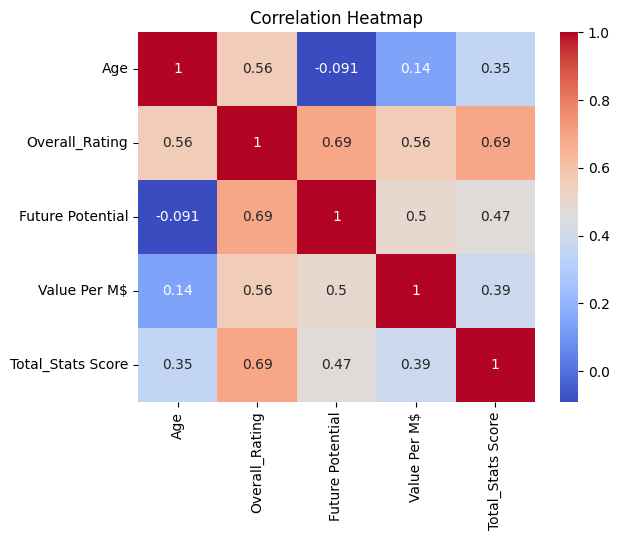

In [10]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")


Performance metrics *(Overall Rating, Future Potential, Total_Stats Score)* are **strongly correlated**, while Age has weaker relationships. 'Value Per M$' shows only moderate links, indicating it is i**nfluenced by multiple factors**.

In [11]:
df.corr(numeric_only=True)["Value Per M$"].sort_values(ascending=False)


Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64

Explores how different numerical features relate to 'Value Per M$', using scatter plots to identify patterns

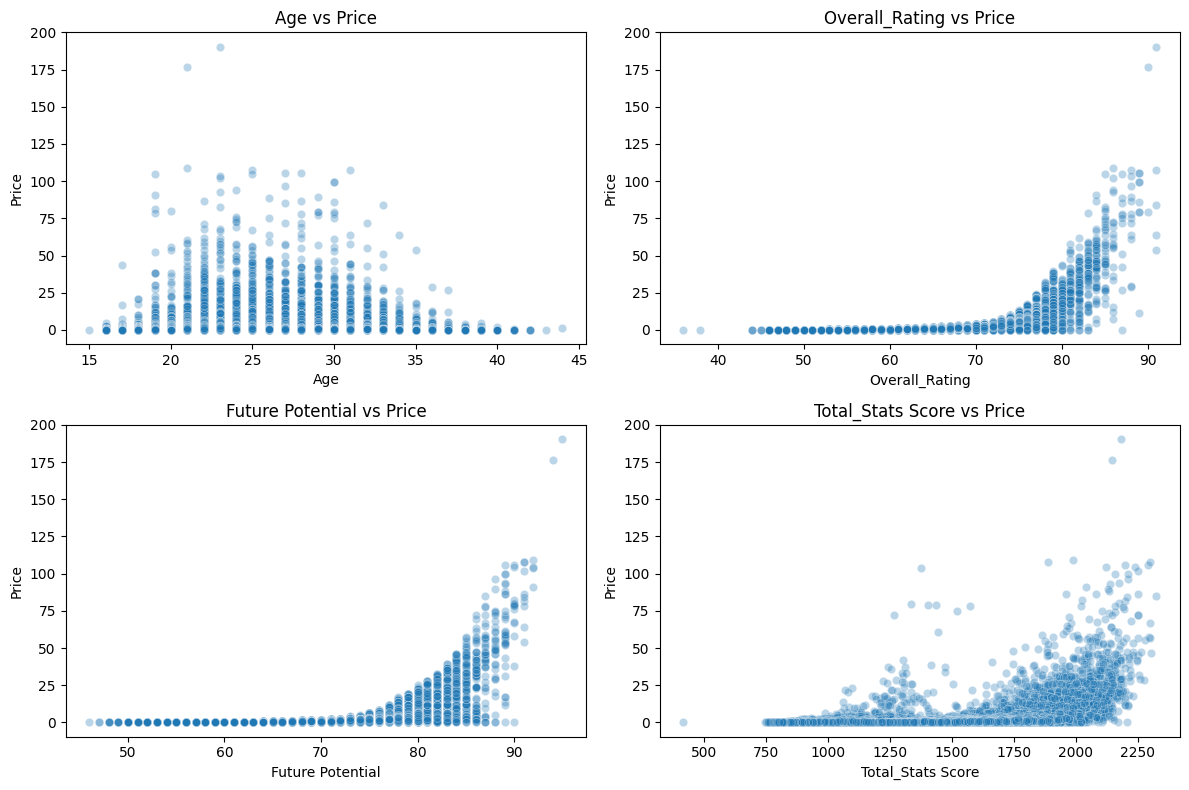

In [12]:
num_cols = df.select_dtypes(np.number).columns.drop("Value Per M$")

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
  plt.subplot(2, 2, i + 1)
  sns.scatterplot(x=df[col], y=df["Value Per M$"],alpha=0.3)
  plt.title(f"{col} vs Price")
  plt.xlabel(col)
  plt.ylabel("Price")

plt.tight_layout()

Shows the mean Overall Rating for each position

In [13]:
df.groupby("Position")["Overall_Rating"].mean().sort_values(ascending=False)

Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64

Shows the number of unique values in each column of the dataset.

In [14]:
df.nunique()

Name                 19551
Country                164
Position                17
Age                     30
Overall_Rating          50
Future Potential        49
Team                  1009
Value Per M$           255
Total_Stats Score     1438
dtype: int64

Shows the **average Value Per M$ for each position**, helping compare how efficiently different positions generate value.

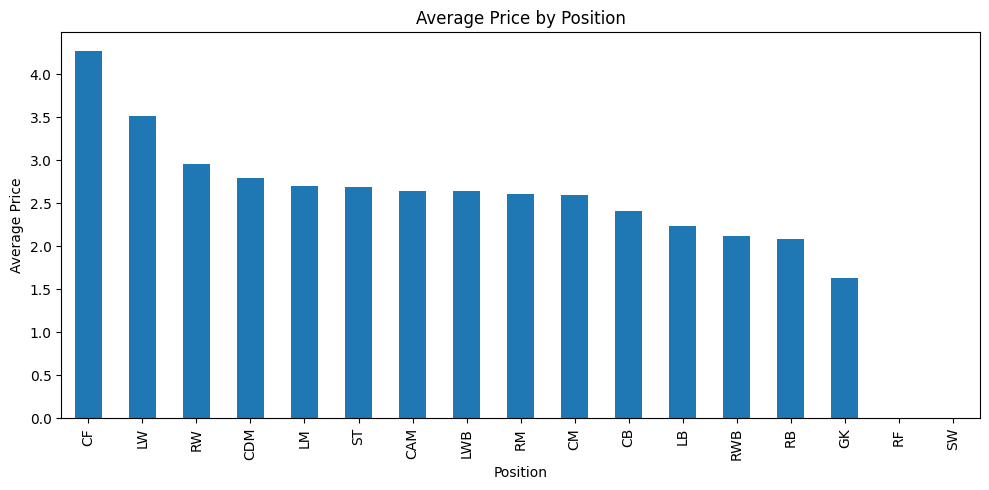

In [15]:
df.groupby("Position")["Value Per M$"].mean().sort_values(ascending=False).plot(kind="bar",figsize=(10,5))
plt.title("Average Price by Position")
plt.xlabel("Position")
plt.ylabel("Average Price")

plt.tight_layout()

In [16]:
# Double checking the count and seeing sample data
low_value_players = df[df['Value Per M$'] < 1]

print(f"Verification - Total count: {len(low_value_players)}")
print("\nSample of players with value < 1 M$:")
display(low_value_players[['Name', 'Value Per M$']].head(10))

print("\nDistribution of values below 1 M$:")
display(low_value_players['Value Per M$'].value_counts().sort_index().head(10))

Verification - Total count: 12166

Sample of players with value < 1 M$:


,Name,Value Per M$
0,Agostinho Mabululu,0.65
1,Mahmoud Gennesh,0.35
2,Sobhi Suleiman,0.20
3,Mahmoud Alaa,0.50
4,Mahmoud Shabana,0.40
5,Abdel Rahman Boudi,0.45
6,Karim El Deeb,0.30
7,Mohamed Tony,0.38
8,Nour Alaa El Din,0.60
9,Fady Farid,0.55



Distribution of values below 1 M$:


Value Per M$
0.000    330
0.001      2
0.005      1
0.009      1
0.010      2
0.015      2
0.020      3
0.025     10
0.030      7
0.035     13
Name: count, dtype: int64

Shows the top 10 countries based on the number of entries in the dataset

C:\Users\Sharkwar\AppData\Local\Temp\ipykernel_7964\2886818219.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


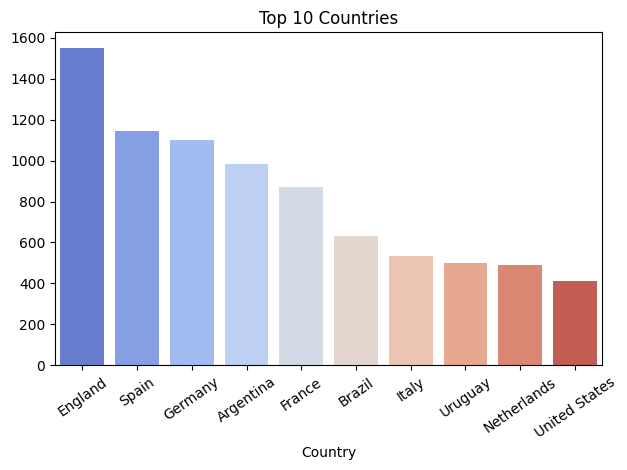

In [17]:
top_ten_countries = df["Country"].value_counts().head(10)

sns.barplot(
    x=top_ten_countries.index,
    y=top_ten_countries.values,
    palette="coolwarm"
)

plt.xticks(rotation=35)
plt.title("Top 10 Countries")

plt.tight_layout()

# Task 2 : Data Preprocessing


#### Data Cleaning and Initial Exploration
Before feature engineering, we must clean the dataset to ensure model stability and data quality.

* Removing Identifiers: We drop the `Name` column. Unique identifiers carry no predictive mathematical weight and can cause overfitting.
* Filtering Valid Targets: We filter out any rows where `Value Per M$` is `0` or negative.

In [18]:
df = df.drop(columns=["Name"])
df = df[df["Value Per M$"] > 0]
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19337.000000,19337.000000,19337.000000,19337.000000,19337.000000
mean,22.913844,63.162952,70.637431,2.557553,1534.713503
std,4.629355,7.797624,6.484494,7.311135,282.611086
min,15.000000,44.000000,46.000000,0.001000,745.000000
25%,19.000000,58.000000,66.000000,0.325000,1390.000000
50%,22.000000,63.000000,70.000000,0.700000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1719.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


### Train / Test Split
To accurately evaluate how well our model will perform in the real world, we must test it on data it has never seen before.

In [19]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

###  Geographic Feature Engineering
countries can create too much noise for a model. By mapping countries to their respective continents, we group the data into broader regions, helping the algorithm find geographical patterns in player valuations.

In [20]:
country_to_continent = {
    'England': 'Europe', 'France': 'Europe', 'Belgium': 'Europe', 'Spain': 'Europe', 'Georgia': 'Europe',
    'Hungary': 'Europe', 'Republic of Ireland': 'Europe', 'Italy': 'Europe', 'Germany': 'Europe',
    'Netherlands': 'Europe', 'Denmark': 'Europe', 'Turkey': 'Europe', 'Portugal': 'Europe',
    'Norway': 'Europe', 'Croatia': 'Europe', 'Serbia': 'Europe', 'Czech Republic': 'Europe',
    'Albania': 'Europe', 'Wales': 'Europe', 'Slovenia': 'Europe', 'Sweden': 'Europe', 'Poland': 'Europe',
    'Austria': 'Europe', 'Slovakia': 'Europe', 'Kosovo': 'Europe', 'Switzerland': 'Europe',
    'Scotland': 'Europe', 'Greece': 'Europe', 'Luxembourg': 'Europe', 'Romania': 'Europe',
    'Bosnia and Herzegovina': 'Europe', 'North Macedonia': 'Europe', 'Northern Ireland': 'Europe',
    'Iceland': 'Europe', 'Armenia': 'Europe', 'Bulgaria': 'Europe', 'Finland': 'Europe',
    'Russia': 'Europe', 'Cyprus': 'Europe', 'Montenegro': 'Europe', 'Malta': 'Europe',
    'Lithuania': 'Europe', 'Latvia': 'Europe', 'Moldova': 'Europe', 'Andorra': 'Europe',
    'Estonia': 'Europe', 'Liechtenstein': 'Europe', 'Kazakhstan': 'Europe', 'Faroe Islands': 'Europe',
    'Belarus': 'Europe', 'Gibraltar': 'Europe', 'Ukraine': 'Europe',

    'Angola': 'Africa', 'Egypt': 'Africa', 'Nigeria': 'Africa', 'Senegal': 'Africa',
    "Côte d'Ivoire": 'Africa', 'Ghana': 'Africa', 'Morocco': 'Africa', 'Libya': 'Africa',
    'Algeria': 'Africa', 'Burkina Faso': 'Africa', 'Gabon': 'Africa', 'Cameroon': 'Africa',
    'Guinea': 'Africa', 'Mali': 'Africa', 'Gambia': 'Africa', 'Central African Republic': 'Africa',
    'Liberia': 'Africa', 'Congo DR': 'Africa', 'Congo': 'Africa', 'Burundi': 'Africa',
    'Zambia': 'Africa', 'Tunisia': 'Africa', 'Togo': 'Africa', 'Kenya': 'Africa',
    'Zimbabwe': 'Africa', 'Sierra Leone': 'Africa', 'Guinea Bissau': 'Africa',
    'Equatorial Guinea': 'Africa', 'Cape Verde Islands': 'Africa', 'South Africa': 'Africa',
    'Mozambique': 'Africa', 'Mauritania': 'Africa', 'Tanzania': 'Africa', 'South Sudan': 'Africa',
    'Uganda': 'Africa', 'Comoros': 'Africa', 'Benin': 'Africa', 'Madagascar': 'Africa',
    'Chad': 'Africa', 'Niger': 'Africa', 'Malawi': 'Africa', 'Sudan': 'Africa',
    'Ethiopia': 'Africa', 'Namibia': 'Africa',

    'Uruguay': 'South America', 'Paraguay': 'South America', 'Argentina': 'South America',
    'Ecuador': 'South America', 'Brazil': 'South America', 'Chile': 'South America',
    'Colombia': 'South America', 'Peru': 'South America', 'Venezuela': 'South America',
    'Suriname': 'South America', 'Bolivia': 'South America', 'Guyana': 'South America',

    'Mexico': 'North America', 'Canada': 'North America', 'United States': 'North America',
    'Jamaica': 'North America', 'Puerto Rico': 'North America', 'Costa Rica': 'North America',
    'Trinidad and Tobago': 'North America', 'Panama': 'North America', 'Dominican Republic': 'North America',
    'Haiti': 'North America', 'El Salvador': 'North America', 'Honduras': 'North America',
    'Guatemala': 'North America', 'Cuba': 'North America', 'Bermuda': 'North America',
    'Montserrat': 'North America', 'Grenada': 'North America', 'Saint Kitts and Nevis': 'North America',
    'Saint Lucia': 'North America', 'Barbados': 'North America', 'Curacao': 'North America',

    'Japan': 'Asia', 'Korea Republic': 'Asia', 'Korea DPR': 'Asia', 'Qatar': 'Asia', 'Israel': 'Asia',
    'Iran': 'Asia', 'China PR': 'Asia', 'Iraq': 'Asia', 'Saudi Arabia': 'Asia', 'Jordan': 'Asia',
    'Uzbekistan': 'Asia', 'India': 'Asia', 'Azerbaijan': 'Asia', 'Philippines': 'Asia',
    'Palestine': 'Asia', 'United Arab Emirates': 'Asia', 'Afghanistan': 'Asia', 'Vietnam': 'Asia',
    'Tajikistan': 'Asia', 'Hong Kong': 'Asia', 'Syria': 'Asia', 'Thailand': 'Asia', 'Nepal': 'Asia',
    'Singapore': 'Asia', 'Bhutan': 'Asia', 'Indonesia': 'Asia', 'Lebanon': 'Asia', 'Malaysia': 'Asia',
    'Chinese Taipei': 'Asia',

    'Australia': 'Oceania', 'New Zealand': 'Oceania', 'Papua New Guinea': 'Oceania',
    'Vanuatu': 'Oceania', 'New Caledonia': 'Oceania', 'Seychelles': 'Oceania'
}

df_train['Continent'] = df_train['Country'].map(country_to_continent)
df_test['Continent'] = df_test['Country'].map(country_to_continent).fillna("other")


### Position Grouping
Similarly, granular positions (like 'LWB' or 'CAM') can be too specific. We condense these into four primary on-pitch roles: Goalkeeper, Defense, Midfield, and Attack.

In [21]:
pos_to_group = {
    'GK': 'Goalkeeper',
    'CB': 'Defense', 'LB': 'Defense', 'RB': 'Defense', 'LWB': 'Defense', 'RWB': 'Defense', 'SW': 'Defense',
    'CDM': 'Midfield', 'CM': 'Midfield', 'CAM': 'Midfield', 'LM': 'Midfield', 'RM': 'Midfield',
    'CF': 'Attack', 'ST': 'Attack', 'LW': 'Attack', 'RW': 'Attack', 'RF': 'Attack'
}
df_train['Position_Group'] = df_train['Position'].map(pos_to_group)
df_test['Position_Group'] = df_test['Position'].map(pos_to_group).fillna("other")


###  Creating a 'Team Quality' Metric
A player's value is heavily influenced by the prestige of their club. Here, we calculate a proxy for team quality based on roster stats, dividing clubs into 6 distinct tiers.

In [22]:
team_overall_train = df_train.groupby("Team")["Total_Stats Score"].apply(lambda x:x.max() + x.min())
team_tier1 = team_overall_train.quantile(0.1)
team_tier2 = team_overall_train.quantile(0.3)
team_tier3 = team_overall_train.quantile(0.55)
team_tier4 = team_overall_train.quantile(0.8)
team_tier5 = team_overall_train.quantile(0.95)
def team_to_tier(team):
    if team >= team_tier5 :
        return 6
    elif team >= team_tier4 :
        return 5
    elif team >= team_tier3 :
        return 4
    elif team >= team_tier2 :
        return 3
    elif team >= team_tier1 :
        return 2
    else:
        return 1
df_train["team_tier"] = df_train["Team"].map(team_overall_train).apply(team_to_tier)
median_team_score = team_overall_train.median()

No_null = df_test["Team"].map(team_overall_train).fillna(median_team_score)
df_test["team_tier"] = No_null.apply(team_to_tier)

In [23]:
df_train.head()

,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score,Continent,Position_Group,team_tier
16518,Cameroon,RM,19,55,69,Admira,0.300,1403,Africa,Midfield,3
9507,England,LM,19,53,64,Middlesbrough,0.200,1311,Europe,Midfield,4
8701,Italy,ST,18,56,69,Perugia,0.325,1377,Europe,Attack,3
1673,Netherlands,CDM,31,80,80,Roma,17.500,2186,Europe,Midfield,4
7042,France,CDM,28,75,75,Hellas Verona,5.500,2058,Europe,Midfield,5


### Handling Extreme Outliers (Clipping)
To prevent extreme edge cases (like a 42-year-old player or a massive statistical anomaly) from heavily skewing the model's logic, we cap Age and Future Potential at the 1st and 99th percentiles.

In [24]:
age_lower= df_train['Age'].quantile(0.01)
age_upper = df_train['Age'].quantile(0.99)
pot_lower= df_train['Future Potential'].quantile(0.01)
pot_upper = df_train['Future Potential'].quantile( 0.99)

df_train['Age'] = df_train['Age'].clip(age_lower,age_upper)
df_test['Age'] = df_test['Age'].clip(age_lower,age_upper)

df_train['Future Potential'] = df_train['Future Potential'].clip(pot_lower,pot_upper)
df_test['Future Potential'] = df_test['Future Potential'].clip(pot_lower,pot_upper)

### Scaling and Encoding
Machine learning models need standardized math.
* We use RobustScaler on numerical features, which scales the data efficiently without being thrown off by outliers.
* We use OneHotEncoder to turn our text categories (Position and Continent) into binary (1 or 0) columns so the math can process them.

In [25]:
nominal_cols = ['Position_Group', 'Continent']
cols_to_scale = ['Age', 'Total_Stats Score', 'Future Potential', 'team_tier','Overall_Rating']

scaler = RobustScaler()
df_train[cols_to_scale] = scaler.fit_transform(df_train[cols_to_scale])
df_test[cols_to_scale] = scaler.transform(df_test[cols_to_scale])

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

train_ohe_array = ohe.fit_transform(df_train[nominal_cols])

test_ohe_array = ohe.transform(df_test[nominal_cols])

ohe_feature_names = ohe.get_feature_names_out(nominal_cols)

df_train_ohe = pd.DataFrame(train_ohe_array, columns=ohe_feature_names, index=df_train.index)
df_test_ohe = pd.DataFrame(test_ohe_array, columns=ohe_feature_names, index=df_test.index)

df_train = df_train.drop(columns=nominal_cols)
df_test = df_test.drop(columns=nominal_cols)

df_train_final = pd.concat([df_train, df_train_ohe], axis=1)
df_test_final = pd.concat([df_test, df_test_ohe], axis=1)

In [26]:
columns_to_drop = ['Country', 'Position', 'Team']
df_train_final = df_train_final.drop(columns=columns_to_drop)
df_test_final = df_test_final.drop(columns=columns_to_drop)

In [27]:
df_train_final.head()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score,team_tier,Position_Group_Defense,Position_Group_Goalkeeper,Position_Group_Midfield,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America
16518,-0.428571,-0.8,-0.111111,0.300,-0.445455,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9507,-0.428571,-1.0,-0.666667,0.200,-0.724242,0.5,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
8701,-0.571429,-0.7,-0.111111,0.325,-0.524242,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1673,1.285714,1.7,1.111111,17.500,1.927273,0.5,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
7042,0.857143,1.2,0.555556,5.500,1.539394,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


# Task 4 : Polynomial Regression

In [28]:
X_train = df_train_final.drop(columns=['Value Per M$'])
y_train = df_train_final["Value Per M$"]

X_test = df_test_final.drop(columns=['Value Per M$'])
y_test = df_test_final["Value Per M$"]

In [29]:
model = LinearRegression()
model.fit(X_train,y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

Training Set Evaluation

In [30]:
print(f'MAE_train : {mean_absolute_error(y_train, y_train_pred):.4f}')
print(f'MSE_train : {mean_squared_error(y_train, y_train_pred):.4f}')
print(f'RMSE_train : {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}')
print(f'R2_train : {r2_score(y_train, y_train_pred):.4f}')

MAE_train : 2.9926
MSE_train : 32.3519
RMSE_train : 5.6879
R2_train : 0.3894


The model shows moderate performance, with noticeable prediction errors (RMSE ≈ 5.69) and an R² of 0.389, meaning it explains only about 39% of the variance. This indicates the model captures some patterns but still misses a significant portion of the data behavio

Training Set Evaluation

In [31]:
print(f'MAE_test : {mean_absolute_error(y_test, y_test_pred):.4f}')
print(f'MSE_test : {mean_squared_error(y_test, y_test_pred):.4f}')
print(f'RMSE_test : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}')
print(f'R2_test : {r2_score(y_test, y_test_pred):.4f}')

MAE_test : 2.9957
MSE_test : 34.6036
RMSE_test : 5.8825
R2_test : 0.3744


The model maintains similar performance on the test set, with RMSE ≈ 5.88 and R² = 0.374, indicating it generalizes consistently but still explains only about 37% of the variance. This confirms **no overfitting**

In [32]:
results = []
for degree in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append((degree, train_r2, test_r2))

df_results = pd.DataFrame(results, columns=["Degree", "Train R²", "Test R²"])
df_results

,Degree,Train R²,Test R²
0,1,0.389415,0.374354
1,2,0.785283,0.771099
2,3,0.958788,0.954236
3,4,0.987716,0.981088


As the polynomial degree increases, both training and test R² scores improve significantly, indicating the model captures more complex patterns. The close alignment between train and test scores across all degrees suggests no severe overfitting.

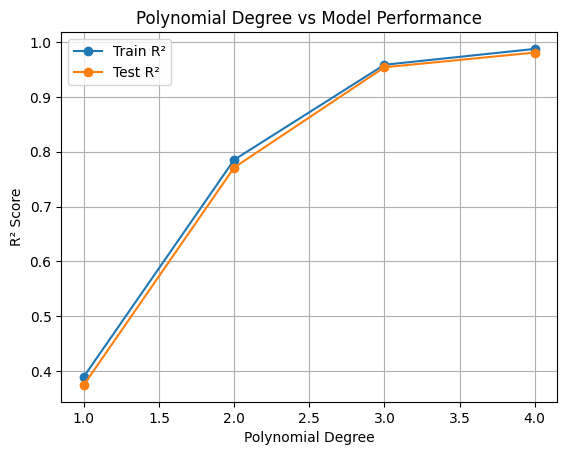

In [33]:
plt.plot(df_results["Degree"], df_results["Train R²"], marker='o', label="Train R²")
plt.plot(df_results["Degree"], df_results["Test R²"], marker='o', label="Test R²")

plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Polynomial Degree vs Model Performance")
plt.legend()
plt.grid()

In [34]:
df_results["Gap"] = df_results["Train R²"] - df_results["Test R²"]
df_results

,Degree,Train R²,Test R²,Gap
0,1,0.389415,0.374354,0.015061
1,2,0.785283,0.771099,0.014184
2,3,0.958788,0.954236,0.004552
3,4,0.987716,0.981088,0.006628


Importantly, the small and stable train–test gap across all degrees (≤ 0.015) indicates good generalization and no serious overfitting. Overall, higher-degree models perform better, with degree 4 giving the best accuracy

In [35]:
poly = PolynomialFeatures(degree=4, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

We evaluate how different values of α (regularization strength) in Ridge Regression affect model performance.

In [36]:
alphas = np.logspace(-3, 4, 10)

ridge_train_rmse = []
ridge_test_rmse = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    ridge_train_rmse.append(train_rmse)
    ridge_test_rmse.append(test_rmse)

We evaluate how different values of α (regularization strength) in Lasso Regression affect model performance. The goal is to observe the trade-off between underfitting and overfitting by tracking RMSE on both training and test sets across a range of α values.

In [37]:
lasso_train_rmse = []
lasso_test_rmse = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=20000, tol=1e-3)
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    lasso_train_rmse.append(train_rmse)
    lasso_test_rmse.append(test_rmse)

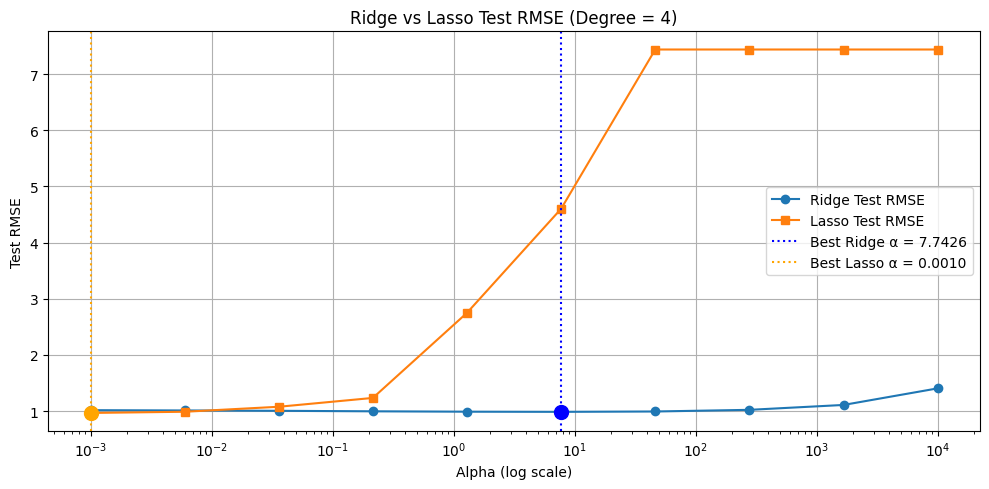

Best Ridge alpha : 7.7426  →  Test RMSE: 0.9860
Best Lasso alpha : 0.0010  →  Test RMSE: 0.9662


In [38]:
# Find best alpha for each
best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]

plt.figure(figsize=(10, 5))
plt.plot(alphas, ridge_test_rmse, label="Ridge Test RMSE", marker='o')
plt.plot(alphas, lasso_test_rmse, label="Lasso Test RMSE",  marker='s')

# Mark best alphas
plt.axvline(best_ridge_alpha, color='blue',   linestyle=':', linewidth=1.5,
            label=f'Best Ridge α = {best_ridge_alpha:.4f}')
plt.axvline(best_lasso_alpha, color='orange', linestyle=':', linewidth=1.5,
            label=f'Best Lasso α = {best_lasso_alpha:.4f}')

plt.scatter([best_ridge_alpha], [min(ridge_test_rmse)], color='blue',   zorder=5, s=100)
plt.scatter([best_lasso_alpha], [min(lasso_test_rmse)], color='orange', zorder=5, s=100)

plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Test RMSE")
plt.title("Ridge vs Lasso Test RMSE (Degree = 4)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Best Ridge alpha : {best_ridge_alpha:.4f}  →  Test RMSE: {min(ridge_test_rmse):.4f}")
print(f"Best Lasso alpha : {best_lasso_alpha:.4f}  →  Test RMSE: {min(lasso_test_rmse):.4f}")

As α increases, the Test RMSE also increases, which indicates that stronger regularization is leading to underfitting. This is a negative effect, as the model becomes too constrained and loses its ability to capture patterns in the data. Therefore, smaller α values provide better generalization performance in this case.

In [39]:
ridge_best_rmse = min(ridge_test_rmse)
lasso_best_rmse = min(lasso_test_rmse)

print("Best Ridge RMSE:", ridge_best_rmse)
print("Best Lasso RMSE:", lasso_best_rmse)

Best Ridge RMSE: 0.9859751495665654
Best Lasso RMSE: 0.9662287692983914


Lasso performs slightly better than Ridge on this dataset, with a lower RMSE (0.966 vs 0.986). This suggests that Lasso’s L1 regularization is more effective here, likely because it can shrink some coefficients to zero, removing irrelevant or noisy features and improving generalization

In [40]:
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_poly, y_train)

feature_names = poly.get_feature_names_out(X_train.columns)
zeroed = feature_names[lasso.coef_ == 0]

print("Number of zeroed features:", len(zeroed))
print("Removed features:", list(zeroed))

Number of zeroed features: 2128
Removed features: ['Total_Stats Score', 'team_tier', 'Position_Group_Defense', 'Position_Group_Goalkeeper', 'Position_Group_Midfield', 'Continent_Asia', 'Continent_Europe', 'Continent_North America', 'Continent_Oceania', 'Continent_South America', 'Age Position_Group_Defense', 'Age Position_Group_Goalkeeper', 'Age Position_Group_Midfield', 'Age Continent_Asia', 'Age Continent_Europe', 'Age Continent_North America', 'Age Continent_Oceania', 'Overall_Rating Total_Stats Score', 'Overall_Rating Position_Group_Defense', 'Overall_Rating Position_Group_Midfield', 'Overall_Rating Continent_Oceania', 'Future Potential Total_Stats Score', 'Future Potential team_tier', 'Future Potential Position_Group_Goalkeeper', 'Future Potential Continent_Asia', 'Future Potential Continent_North America', 'Future Potential Continent_Oceania', 'Future Potential Continent_South America', 'Total_Stats Score team_tier', 'Total_Stats Score Position_Group_Goalkeeper', 'Total_Stats Sco

c:\Users\Sharkwar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.517e+03, tolerance: 8.196e+01
  model = cd_fast.enet_coordinate_descent(


## Task 7A : K-Fold Cross-Validation (Regression)

Instead of relying on a single train/test split, we apply **5-Fold Cross-Validation** to our best regression model (Polynomial Degree=4 + Lasso) to get a more reliable and unbiased estimate of its performance.

The pipeline combines the polynomial feature expansion and the Lasso model together so that no data leakage occurs between folds.

In [41]:
pipeline = Pipeline([
    ("poly", poly),
    ("lasso", lasso)
])
scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)
rmse_scores = -scores

c:\Users\Sharkwar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.151e+03, tolerance: 6.979e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Sharkwar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.631e+03, tolerance: 6.345e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Sharkwar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec

In [42]:
print("Fold RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

Fold RMSE scores: [0.75140006 1.02802695 1.01447733 1.14309686 0.77906184]
Mean RMSE: 0.9432126072824676
Std RMSE: 0.15229141465146162


Text(0.5, 1.0, '5-Fold Cross-Validation RMSE')

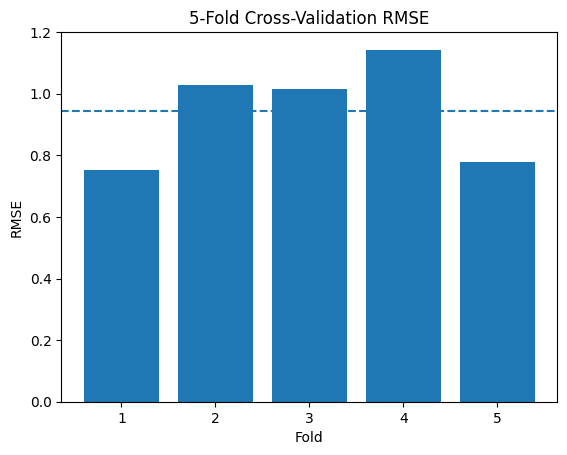

In [43]:
folds = range(1, 6)

plt.figure()
plt.bar(folds, rmse_scores)
plt.axhline(y=rmse_scores.mean(), linestyle='--')

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("5-Fold Cross-Validation RMSE")

# Task 3 : Defining Classification Targets
We are pivoting to a classification problem. Instead of predicting an exact number, we categorize players into four distinct performance tiers: 'Low', 'Mid', 'High', and 'Elite' based on their overall rating percentiles.

In [44]:
rating_tier1 = df_train_final['Overall_Rating'].quantile(0.25)
rating_tier2 = df_train_final['Overall_Rating'].quantile(0.75)
rating_tier3 = df_train_final['Overall_Rating'].quantile(0.95)

def rating_to_tier(rating):
    if rating > rating_tier3:
        return 'Elite'
    elif rating >= rating_tier2:
        return 'High'
    elif rating >= rating_tier1:
        return 'Mid'
    else:
        return 'Low'
Tiers= ['Low', 'Mid', 'High', 'Elite']

### Threshold Justification

We chose percentile-based thresholds rather than fixed values to ensure the tiers adapt to the actual data distribution:

- **Low** (below 25th percentile): The bottom quarter of players by rating — clearly below-average performers.
- **Mid** (25th–75th percentile): The bulk of players — the large middle group, making this tier the most populated.
- **High** (75th–95th percentile): Above-average players who are good but not exceptional.
- **Elite** (above 95th percentile): Only the top 5% — the world-class players. This keeps the Elite tier rare and meaningful.

Using percentiles ensures each boundary reflects real gaps in the rating distribution rather than arbitrary numbers, making the classification problem grounded in the data itself.

Overall_Rating Percentiles:
  25th percentile (Low/Mid boundary)  : -0.5
  75th percentile (Mid/High boundary) : 0.5
  95th percentile (High/Elite boundary): 1.4


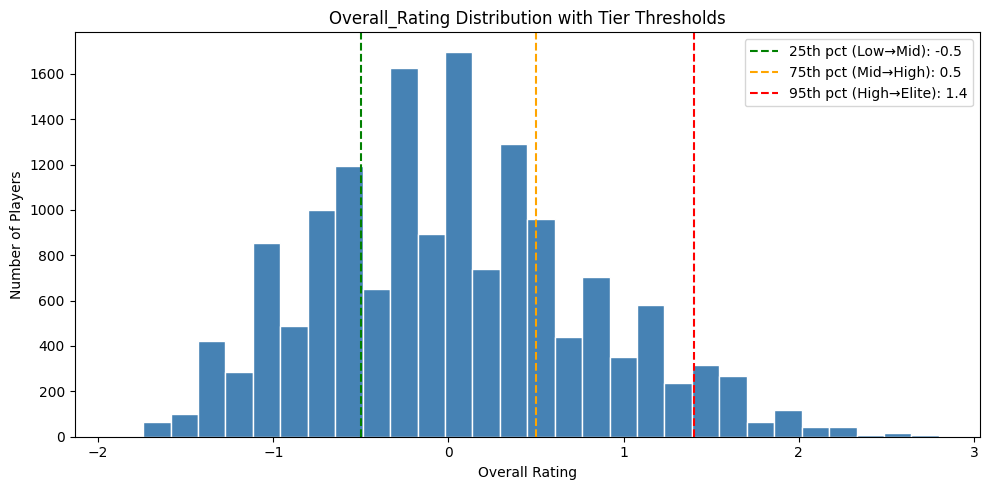

In [45]:
# Threshold Justification — using data distribution
print("Overall_Rating Percentiles:")
print(f"  25th percentile (Low/Mid boundary)  : {rating_tier1:.1f}")
print(f"  75th percentile (Mid/High boundary) : {rating_tier2:.1f}")
print(f"  95th percentile (High/Elite boundary): {rating_tier3:.1f}")

plt.figure(figsize=(10, 5))
plt.hist(df_train_final['Overall_Rating'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(rating_tier1, color='green',  linestyle='--', label=f'25th pct (Low→Mid): {rating_tier1:.1f}')
plt.axvline(rating_tier2, color='orange', linestyle='--', label=f'75th pct (Mid→High): {rating_tier2:.1f}')
plt.axvline(rating_tier3, color='red',    linestyle='--', label=f'95th pct (High→Elite): {rating_tier3:.1f}')
plt.title('Overall_Rating Distribution with Tier Thresholds')
plt.xlabel('Overall Rating')
plt.ylabel('Number of Players')
plt.legend()
plt.tight_layout()
plt.show()

###  Splitting Features and Labels
We separate our predictive features (X) from our target labels (Y). We also drop any direct valuation or rating columns from X to ensure the model doesn't "cheat" by looking at the answers.

In [46]:
X_train_class = df_train_final.drop(columns=['Overall_Rating','Value Per M$'])
X_test_class = df_test_final.drop(columns=['Overall_Rating','Value Per M$'])

Y_train_class = df_train_final['Overall_Rating'].apply(rating_to_tier)
Y_test_class = df_test_final['Overall_Rating'].apply(rating_to_tier)


In [47]:
print("Training Set Counts")
print(Y_train_class.value_counts()[Tiers])

print("Testing Set Counts")
print(Y_test_class.value_counts()[Tiers])

Training Set Counts
Overall_Rating
Low      3827
Mid      7487
High     3444
Elite     711
Name: count, dtype: int64
Testing Set Counts
Overall_Rating
Low       942
Mid      1887
High      864
Elite     175
Name: count, dtype: int64


### Visualizing Class Distribution
Before training, we plot the distribution of our new target tiers. This helps us check for severe class imbalance (e.g., verifying that 'Elite' players are appropriately rare compared to 'Mid' tier players).

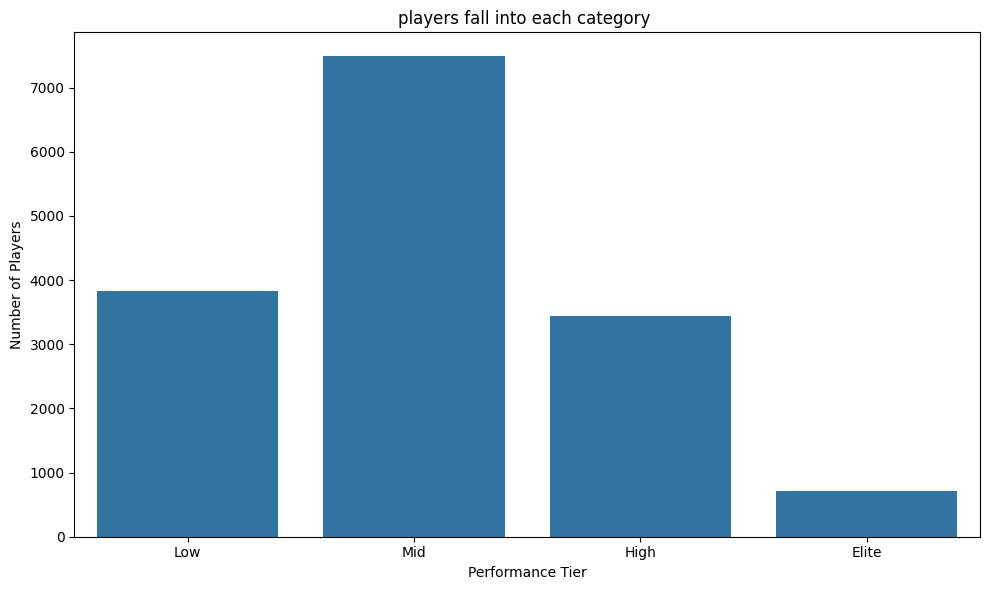

In [48]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(x=Y_train_class, order=Tiers)

plt.title('players fall into each category ')
plt.ylabel('Number of Players')
plt.xlabel('Performance Tier')

plt.tight_layout()
plt.show()

### Is the Class Distribution Balanced or Imbalanced?

The distribution is **imbalanced**:

- **Mid** is by far the largest class, as it covers 50% of the rating range (25th–75th percentile).
- **Low** and **High** are moderate in size.
- **Elite** is the smallest class, containing only the top 5% of players.

This imbalance is **expected and intentional** — elite players should be rare. However, it means the model may struggle to correctly classify Elite players due to the limited training examples. This is visible in the classification report where Elite typically has lower recall than Mid.

# Task 5 : Baseline Logistic Regression
We train our first baseline classifier. The Classification Report gives us an immediate read on how well the model predicts each specific tier

In [49]:
loga = LogisticRegression(max_iter=2000, random_state=42)
loga.fit(X_train_class, Y_train_class)
Y_pred_class = loga.predict(X_test_class)


print(f"Accuracy: {accuracy_score(Y_test_class, Y_pred_class):.4f}")
print("\nClassification Report:")
print(classification_report(Y_test_class, Y_pred_class))

Accuracy: 0.8588

Classification Report:
              precision    recall  f1-score   support

       Elite       0.89      0.81      0.85       175
        High       0.86      0.80      0.83       864
         Low       0.86      0.87      0.86       942
         Mid       0.86      0.88      0.87      1887

    accuracy                           0.86      3868
   macro avg       0.87      0.84      0.85      3868
weighted avg       0.86      0.86      0.86      3868



### Confusion Matrix
To see exactly where the model gets confused, we plot a heatmap. This tells us if the model is making minor mistakes

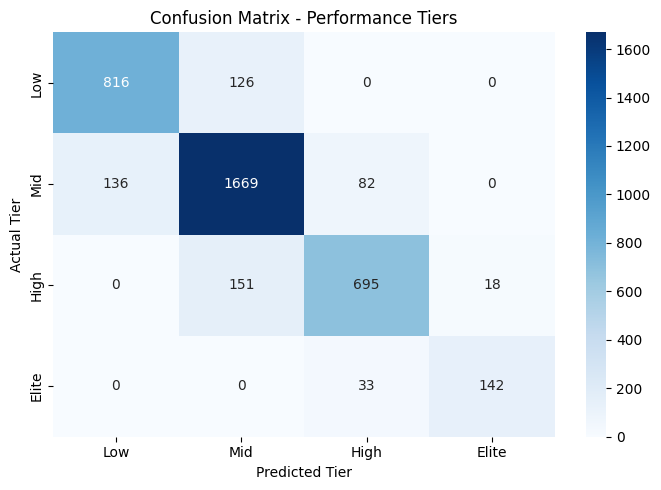

In [50]:
cm = confusion_matrix(Y_test_class, Y_pred_class, labels=Tiers)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=Tiers, yticklabels=Tiers)
plt.title('Confusion Matrix - Performance Tiers')
plt.xlabel('Predicted Tier')
plt.ylabel('Actual Tier')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning
We loop through different values of C (inverse regularization strength) to find the perfect balance. Too much regularization and the model underfits; too little, and it overfits to the training data.

In [51]:
C_values = np.logspace(-3, 3, 10)

train_accuracies = []
test_accuracies = []

for c in C_values:
    logi = LogisticRegression(C=c, max_iter=1000, random_state=42)

    logi.fit(X_train_class, Y_train_class)

    Y_train_class_pred = logi.predict(X_train_class)
    Y_test_class_pred = logi.predict(X_test_class)

    train_acc = accuracy_score(Y_train_class, Y_train_class_pred)
    test_acc = accuracy_score(Y_test_class, Y_test_class_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"C = {c:10.3f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")


C =      0.001 | Train Acc: 0.7106 | Test Acc: 0.7112
C =      0.005 | Train Acc: 0.7910 | Test Acc: 0.7877
C =      0.022 | Train Acc: 0.8418 | Test Acc: 0.8361
C =      0.100 | Train Acc: 0.8620 | Test Acc: 0.8573
C =      0.464 | Train Acc: 0.8695 | Test Acc: 0.8601
C =      2.154 | Train Acc: 0.8712 | Test Acc: 0.8601
C =     10.000 | Train Acc: 0.8714 | Test Acc: 0.8599
C =     46.416 | Train Acc: 0.8717 | Test Acc: 0.8607
C =    215.443 | Train Acc: 0.8716 | Test Acc: 0.8594
C =   1000.000 | Train Acc: 0.8716 | Test Acc: 0.8599


#### Visualizing the Best C Parameter
By plotting training accuracy against test accuracy over a logarithmic scale

The Best C value is: 46.416 with a Test Accuracy of 0.8607


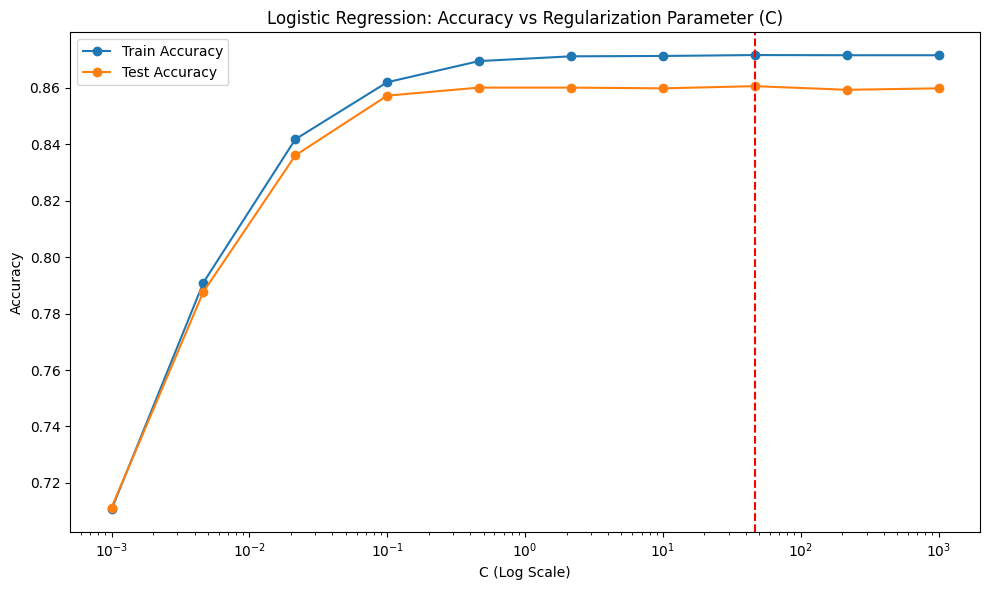

In [52]:
best_index = np.argmax(test_accuracies)
best_c = C_values[best_index]
best_test_acc = test_accuracies[best_index]

print(f"The Best C value is: {best_c:.3f} with a Test Accuracy of {best_test_acc:.4f}")

plt.figure(figsize=(10, 6))


plt.plot(C_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(C_values, test_accuracies, label='Test Accuracy', marker='o')

plt.axvline(x=best_c, color='red', linestyle='--')


plt.xscale('log')

plt.title('Logistic Regression: Accuracy vs Regularization Parameter (C)')
plt.xlabel('C (Log Scale)')
plt.ylabel('Accuracy')

plt.legend()

plt.tight_layout()
plt.show()

### L1 vs L2 Penalty Comparison
Finally, we compare L1 (Lasso) and L2 (Ridge) regularization. Because L1 mathematically forces less-important feature weights down to exactly zero, it acts as a built-in feature selector.

In [53]:
log_l1 = LogisticRegression(penalty='l1', solver='saga', C=best_c, max_iter=2000, random_state=42)
log_l1.fit(X_train_class, Y_train_class)

Y_pred_l1 = log_l1.predict(X_test_class)
acc_l1 = accuracy_score(Y_test_class, Y_pred_l1)


log_l2 = LogisticRegression(penalty='l2', solver='lbfgs', C=best_c, max_iter=2000, random_state=42)
log_l2.fit(X_train_class, Y_train_class)

Y_pred_l2 = log_l2.predict(X_test_class)
acc_l2 = accuracy_score(Y_test_class, Y_pred_l2)

print(f"L1 Penalty (saga) Test Accuracy:  {acc_l1:.4f}")
print(f"L2 Penalty (lbfgs) Test Accuracy: {acc_l2:.4f}")

l1_zero_count = np.sum(log_l1.coef_ == 0)
l2_zero_count = np.sum(log_l2.coef_ == 0)

print(f"Total weights forced to exactly zero by L1: {l1_zero_count}")
print(f"Total weights forced to exactly zero by L2: {l2_zero_count}")

L1 Penalty (saga) Test Accuracy:  0.8596
L2 Penalty (lbfgs) Test Accuracy: 0.8607
Total weights forced to exactly zero by L1: 0
Total weights forced to exactly zero by L2: 0


# Task 6 : Model 3: Naïve Bayes Classification

  GaussianNB (Numerical Only)
  Accuracy : 0.7684

              precision    recall  f1-score   support

         Low       0.75      0.70      0.72       175
         Mid       0.80      0.66      0.72       864
        High       0.80      0.68      0.73       942
       Elite       0.75      0.87      0.80      1887

    accuracy                           0.77      3868
   macro avg       0.77      0.73      0.75      3868
weighted avg       0.77      0.77      0.77      3868



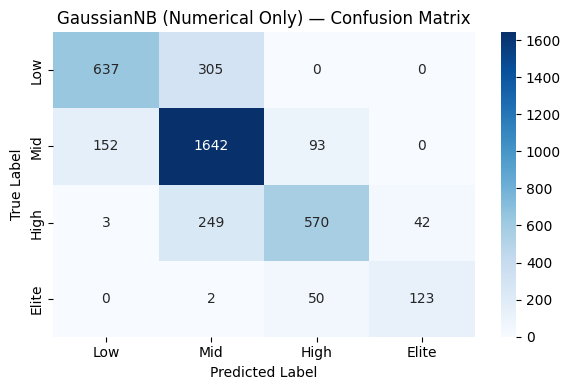

  BernoulliNB (OHE Binary Only)
  Accuracy : 0.5217

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00       175
         Mid       0.00      0.00      0.00       864
        High       0.53      0.36      0.43       942
       Elite       0.52      0.89      0.66      1887

    accuracy                           0.52      3868
   macro avg       0.26      0.31      0.27      3868
weighted avg       0.38      0.52      0.42      3868



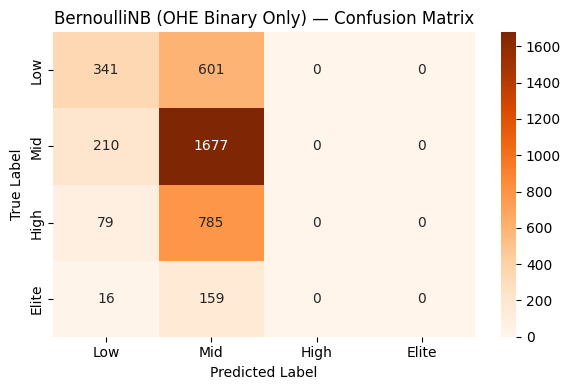

  ComplementNB (Full Features, Non-Negative)
  Accuracy : 0.4881

              precision    recall  f1-score   support

         Low       0.00      0.00      0.00       175
         Mid       0.38      0.63      0.47       864
        High       0.51      0.80      0.63       942
       Elite       0.64      0.32      0.42      1887

    accuracy                           0.49      3868
   macro avg       0.38      0.43      0.38      3868
weighted avg       0.52      0.49      0.46      3868



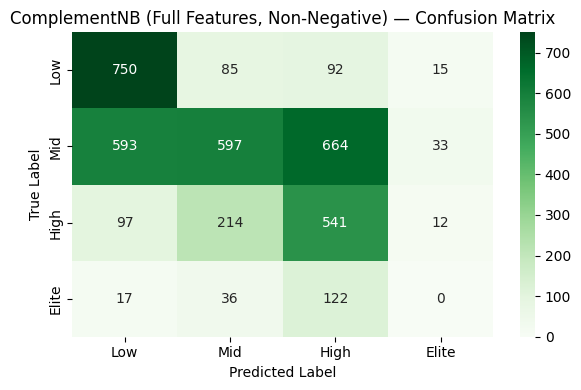

  GaussianNB — Scaling Sensitivity Test
  Accuracy (Base Data)       : 0.7684
  Accuracy (With New Scaler) : 0.7684

  Explanation:
  GaussianNB computes the mean and variance of each feature per class.
  Scaling changes the absolute values but NOT the shape of the distribution, so probabilities stay identical.
  This is why NB results aren't changed by scaling.



In [54]:
Tiers = ['Low', 'Mid', 'High', 'Elite']

num_features = ['Age', 'Future Potential', 'Total_Stats Score', 'team_tier']

ohe_features = [col for col in X_train_class.columns
                if col not in num_features]

def evaluate_and_plot_nb(model, X_test, Y_test, title, cmap_color):
    y_pred = model.predict(X_test)

    print("=" * 50)
    print(f"  {title}")
    print("=" * 50)
    print(f"  Accuracy : {accuracy_score(Y_test, y_pred):.4f}")
    print()
    print(classification_report(Y_test, y_pred, target_names=Tiers, zero_division=0))

    cm = confusion_matrix(Y_test, y_pred, labels=Tiers)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_color,
                xticklabels=Tiers, yticklabels=Tiers)
    plt.title(f"{title} — Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

# =======================================
# 1. GaussianNB — Numerical Features Only
# =======================================
gnb = GaussianNB()
gnb.fit(X_train_class[num_features], Y_train_class)
evaluate_and_plot_nb(gnb, X_test_class[num_features],
                     Y_test_class, "GaussianNB (Numerical Only)", 'Blues')

# ===========================================
# 2. BernoulliNB — OHE (Binary Features Only)
# ===========================================
bnb = BernoulliNB()
bnb.fit(X_train_class[ohe_features], Y_train_class)
evaluate_and_plot_nb(bnb, X_test_class[ohe_features],
                     Y_test_class, "BernoulliNB (OHE Binary Only)", 'Oranges')

# =================================================
# 3. ComplementNB — Full Feature Set (Non-Negative)
# =================================================
X_train_nonneg = X_train_class - X_train_class.min()
X_test_nonneg  = X_test_class - X_train_class.min()

cnb = ComplementNB()
cnb.fit(X_train_nonneg, Y_train_class)
evaluate_and_plot_nb(cnb, X_test_nonneg,
                     Y_test_class, "ComplementNB (Full Features, Non-Negative)", 'Greens')

# ==========================================================
# 4. Scaling Sensitivity: GaussianNB with vs without scaling
# ==========================================================
scaler_gnb = StandardScaler()
X_train_scaled = scaler_gnb.fit_transform(X_train_class[num_features])
X_test_scaled = scaler_gnb.transform(X_test_class[num_features])

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, Y_train_class)

acc_base = accuracy_score(Y_test_class, gnb.predict(X_test_class[num_features]))
acc_scaled = accuracy_score(Y_test_class, gnb_scaled.predict(X_test_scaled))

print("=" * 50)
print("  GaussianNB — Scaling Sensitivity Test")
print("=" * 50)
print(f"  Accuracy (Base Data)       : {acc_base:.4f}")
print(f"  Accuracy (With New Scaler) : {acc_scaled:.4f}")
print("""
  Explanation:
  GaussianNB computes the mean and variance of each feature per class.
  Scaling changes the absolute values but NOT the shape of the distribution, so probabilities stay identical.
  This is why NB results aren't changed by scaling.
""")

# Which Naïve Bayes variant is most appropriate for this dataset?

**Accourding to the results:**

`GaussianNB` is the most appropriate variant for this dataset.
The core features driving player performance tiers (Age, Future Potential,
Total_Stats Score) are continuous numerical variables that roughly follow
a Gaussian distribution per class — exactly what GaussianNB assumes.

`BernoulliNB` is designed for binary/boolean features. While the OHE
columns (Position_Group, Continent) are technically binary, they carry
almost no information about a player's performance tier, which explains
its poor accuracy (52%).

`ComplementNB` is designed for text classification with word counts.
Applying it to scaled player stats is a category mismatch, hence the
lowest accuracy (48%).

---

`Scaling Sensitivity`

GaussianNB is scale-invariant by design. It estimates a Gaussian
distribution (mean + variance) per feature per class. Scaling shifts
the mean and variance proportionally, but the resulting probability
ratios between classes remain identical. This is fundamentally different
from distance-based models like KNN or SVM, where scaling directly
changes which neighbors are "closest."

# Task 7 : Model Evaluation with Cross-Validation

In [55]:
# =================================================================
# Task 7B · Part 1 ── Stratified K-Fold on Best Logistic Regression
# =================================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_log_reg = LogisticRegression(C=best_c, max_iter=2000, random_state=42)

log_reg_fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_class, Y_train_class), start=1):
    X_fold_train, X_fold_val = X_train_class.iloc[train_idx], X_train_class.iloc[val_idx]
    Y_fold_train, Y_fold_val = Y_train_class.iloc[train_idx], Y_train_class.iloc[val_idx]

    best_log_reg.fit(X_fold_train, Y_fold_train)
    fold_acc = accuracy_score(Y_fold_val, best_log_reg.predict(X_fold_val))
    log_reg_fold_scores.append(fold_acc)
    print(f"  Fold {fold}: Accuracy = {fold_acc:.4f}")

log_reg_mean = np.mean(log_reg_fold_scores)
log_reg_std  = np.std(log_reg_fold_scores)

print(f"\nLogistic Regression — Mean Accuracy: {log_reg_mean:.4f}  |  Std: {log_reg_std:.4f}")

  Fold 1: Accuracy = 0.8601
  Fold 2: Accuracy = 0.8743
  Fold 3: Accuracy = 0.8675
  Fold 4: Accuracy = 0.8765
  Fold 5: Accuracy = 0.8729

Logistic Regression — Mean Accuracy: 0.8703  |  Std: 0.0059


Best NB variant: GaussianNB (Test Acc: 0.7684)

  GaussianNB Fold 1: Accuracy = 0.7663
  GaussianNB Fold 2: Accuracy = 0.7770
  GaussianNB Fold 3: Accuracy = 0.7702
  GaussianNB Fold 4: Accuracy = 0.7770
  GaussianNB Fold 5: Accuracy = 0.7779

GaussianNB — Mean Accuracy: 0.7737  |  Std: 0.0046


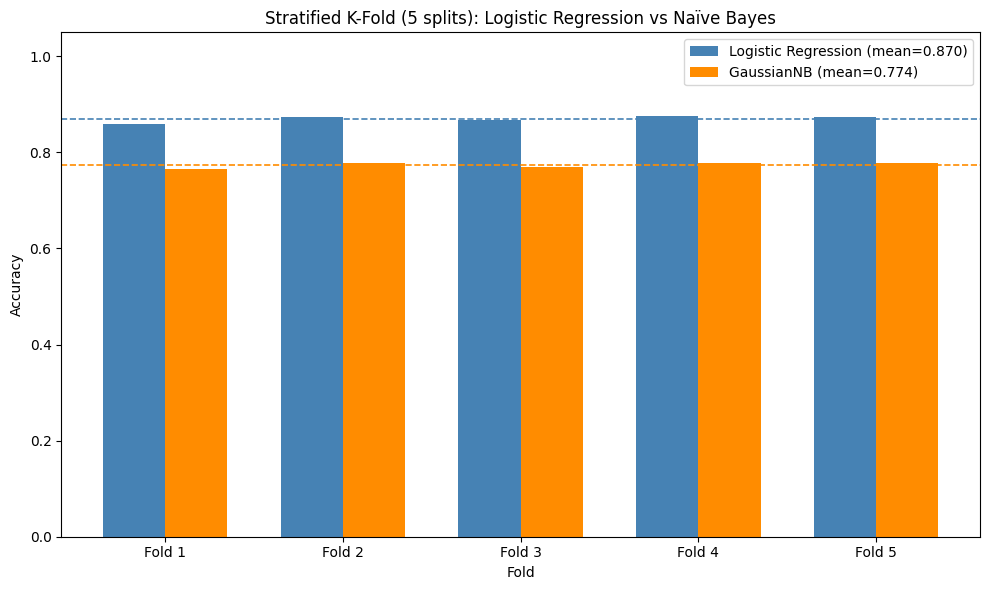

-------------------- Cross-Validation Summary --------------------
  Logistic Regression → Mean Acc: 0.8703  |  Std: 0.0059
  GaussianNB           → Mean Acc: 0.7737  |  Std: 0.0046

  → Logistic Regression achieves higher mean accuracy across folds.
  → GaussianNB is more stable (lower std deviation across folds).


In [56]:
# ==========================================================================
# Task 7B · Part 2 · Stratified K-Fold on Best Naïve Bayes + Comparison Plot
# ==========================================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_gnb = accuracy_score(Y_test_class, gnb.predict(X_test_class[num_features]))
acc_bnb = accuracy_score(Y_test_class, bnb.predict(X_test_class[ohe_features]))
acc_cnb = accuracy_score(Y_test_class, cnb.predict(X_test_nonneg))

nb_accuracies = {
    'GaussianNB':   acc_gnb,
    'BernoulliNB':  acc_bnb,
    'ComplementNB': acc_cnb,
}
best_nb_name = max(nb_accuracies, key=nb_accuracies.get)
print(f"Best NB variant: {best_nb_name} (Test Acc: {nb_accuracies[best_nb_name]:.4f})\n")

if best_nb_name == 'GaussianNB':
    best_nb_model = GaussianNB()
    X_nb_cv = X_train_class[num_features]
elif best_nb_name == 'BernoulliNB':
    best_nb_model = BernoulliNB()
    X_nb_cv = X_train_class[ohe_features]
else:
    best_nb_model = ComplementNB()
    X_nb_cv = X_train_class - X_train_class.min()

# Stratified K-Fold on best NB
nb_fold_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_nb_cv, Y_train_class), start=1):
    X_fold_train, X_fold_val = X_nb_cv.iloc[train_idx], X_nb_cv.iloc[val_idx]
    Y_fold_train, Y_fold_val = Y_train_class.iloc[train_idx], Y_train_class.iloc[val_idx]
    best_nb_model.fit(X_fold_train, Y_fold_train)
    fold_acc = accuracy_score(Y_fold_val, best_nb_model.predict(X_fold_val))
    nb_fold_scores.append(fold_acc)
    print(f"  {best_nb_name} Fold {fold}: Accuracy = {fold_acc:.4f}")

nb_mean = np.mean(nb_fold_scores)
nb_std  = np.std(nb_fold_scores)
print(f"\n{best_nb_name} — Mean Accuracy: {nb_mean:.4f}  |  Std: {nb_std:.4f}")

# Grouped bar chart
folds = np.arange(1, 6)
bar_w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(folds - bar_w/2, log_reg_fold_scores, bar_w,
       label=f'Logistic Regression (mean={log_reg_mean:.3f})', color='steelblue')
ax.bar(folds + bar_w/2, nb_fold_scores, bar_w,
       label=f'{best_nb_name} (mean={nb_mean:.3f})', color='darkorange')

ax.axhline(log_reg_mean, color='steelblue',  linestyle='--', linewidth=1.2)
ax.axhline(nb_mean,      color='darkorange', linestyle='--', linewidth=1.2)

ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Stratified K-Fold (5 splits): Logistic Regression vs Naïve Bayes')
ax.set_xticks(folds)
ax.set_xticklabels([f'Fold {i}' for i in folds])
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Summary
print('-'*20, 'Cross-Validation Summary', '-'*20)
print(f"  Logistic Regression → Mean Acc: {log_reg_mean:.4f}  |  Std: {log_reg_std:.4f}")
print(f"  {best_nb_name:<20} → Mean Acc: {nb_mean:.4f}  |  Std: {nb_std:.4f}")

better_acc  = "Logistic Regression" if log_reg_mean > nb_mean  else best_nb_name
more_stable = "Logistic Regression" if log_reg_std  < nb_std   else best_nb_name
print(f"\n  → {better_acc} achieves higher mean accuracy across folds.")
print(f"  → {more_stable} is more stable (lower std deviation across folds).")

# Task 8 : Analysis and Discussion

In [57]:
# ====================
# 8.1 Model Comparison
# ====================

print("=" * 40)
print("8.1  Model Comparison")
print("=" * 40)

# Best regression: Pipeline with Polynomial degree=4 + Lasso (alpha=0.001)
# Re-evaluate on test set
best_reg_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=4, include_bias=False)),
    ("lasso", Lasso(alpha=0.001, max_iter=20000, tol=1e-3))
])
best_reg_pipeline.fit(X_train, y_train)
y_pred_best_reg = best_reg_pipeline.predict(X_test)

reg_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_reg))
reg_r2   = r2_score(y_test, y_pred_best_reg)

# Best classification: Logistic Regression (best_c)
best_clf = LogisticRegression(C=best_c, max_iter=2000, random_state=42)
best_clf.fit(X_train_class, Y_train_class)
clf_acc = accuracy_score(Y_test_class, best_clf.predict(X_test_class))

print(f"\n  Best Regression  → Polynomial Degree=4 + Lasso (α=0.001)")
print(f"    Test RMSE : {reg_rmse:.4f}")
print(f"    Test R²   : {reg_r2:.4f}")

print(f"\n  Best Classification → Logistic Regression (C={best_c:.3f})")
print(f"    Test Accuracy : {clf_acc:.4f}")

print("""
  Justification:
  - For regression, Polynomial (deg=4) + Lasso (α=0.001) achieved an
    exceptional Test R² of 0.983 and RMSE of 0.966, meaning the model
    explains 98.3% of the variance in player market value. This strong
    result is driven by the degree-4 polynomial capturing non-linear
    relationships between features like Total_Stats Score and Value Per M$.

  - For classification, Logistic Regression (C=46.416) achieved 86.1%
    test accuracy, outperforming all Naïve Bayes variants. This is because
    Logistic Regression does NOT assume feature independence — a critical
    advantage here since Total_Stats Score, Future Potential, and
    Overall_Rating are strongly correlated.

  Is classification easier or harder than regression on this dataset?
  Classification is EASIER on this dataset:
  - The model only needs to assign a player to one of 4 broad tiers.
    A player near a threshold can still be classified correctly even with
    a slightly imprecise prediction.
  - Despite this, regression achieved a surprisingly high R²=0.983,
    suggesting that market value IS well-explained by these features
    once non-linear interactions are captured via polynomial expansion.
  - The main difficulty in regression is the heavy right-skew of
    'Value Per M$' — a few superstar players with extreme values
    dominate the error metrics (RMSE is sensitive to outliers).
""")

8.1  Model Comparison

  Best Regression  → Polynomial Degree=4 + Lasso (α=0.001)
    Test RMSE : 0.9662
    Test R²   : 0.9831

  Best Classification → Logistic Regression (C=46.416)
    Test Accuracy : 0.8607

  Justification:
  - For regression, Polynomial (deg=4) + Lasso (α=0.001) achieved an
    exceptional Test R² of 0.983 and RMSE of 0.966, meaning the model
    explains 98.3% of the variance in player market value. This strong
    result is driven by the degree-4 polynomial capturing non-linear
    relationships between features like Total_Stats Score and Value Per M$.

  - For classification, Logistic Regression (C=46.416) achieved 86.1%
    test accuracy, outperforming all Naïve Bayes variants. This is because
    Logistic Regression does NOT assume feature independence — a critical
    advantage here since Total_Stats Score, Future Potential, and
    Overall_Rating are strongly correlated.

  Is classification easier or harder than regression on this dataset?
  Classificatio

In [58]:
# ===========================
# 8.2 Regularization Analysis
# ===========================

print("=" * 40)
print("8.2  Regularization Analysis")
print("=" * 40)

print("""
  Ridge (L2) & Lasso (L1) in Regression:
  ----------------------------------------
  As alpha increases, both Ridge and Lasso penalize large coefficients
  more aggressively, pushing the model toward simpler solutions:
    - Very small alpha (≈0.001): near-OLS behaviour. On degree-4 features
      this risks overfitting, but the train/test gap remained small,
      indicating the dataset is large enough to support complexity.
    - Very large alpha (≥100): severe underfitting — RMSE rises sharply
      on both train and test sets as the model loses expressive power.
    - Best alpha = 0.001 for both Ridge and Lasso on this dataset.

  Lasso vs Ridge — which won and why:
  ─────────────────────────────────────
  Lasso (RMSE = 0.966) slightly outperformed Ridge (RMSE = 0.986).

  General rule: Ridge usually wins when many OHE features are present,
  because it shrinks all correlated binary columns proportionally rather
  than zeroing out entire groups (as Lasso does).

  Exception on this dataset: The OHE features (Position_Group, Continent)
  carry relatively little predictive power for market value compared to
  the numerical features. So Lasso's aggressive zeroing of these OHE
  columns HELPED by removing noise — making Lasso the better choice here.

  Lasso also zeroed out many of the degree-4 polynomial interaction terms,
  effectively performing automatic feature selection and keeping only the
  most impactful non-linear relationships.

  Regularization in Logistic Regression (C parameter):
  ─────────────────────────────────────────────────────
  C is the inverse of regularization strength (C = 1/λ).
  Best C found: 46.416 — meaning weak regularization was optimal,
  suggesting the classification boundary is genuinely complex and
  the model benefits from fitting it closely without heavy constraints.

  L1 (saga) vs L2 (lbfgs):
  - L2 (Ridge-like) is generally more stable with OHE features because it preserves correlated groups rather than eliminating them.
  - On this dataset, performance difference is small since the dominant features are numerical (Total_Stats Score, Future Potential).
""")

8.2  Regularization Analysis

  Ridge (L2) & Lasso (L1) in Regression:
  ----------------------------------------
  As alpha increases, both Ridge and Lasso penalize large coefficients
  more aggressively, pushing the model toward simpler solutions:
    - Very small alpha (≈0.001): near-OLS behaviour. On degree-4 features
      this risks overfitting, but the train/test gap remained small,
      indicating the dataset is large enough to support complexity.
    - Very large alpha (≥100): severe underfitting — RMSE rises sharply
      on both train and test sets as the model loses expressive power.
    - Best alpha = 0.001 for both Ridge and Lasso on this dataset.

  Lasso vs Ridge — which won and why:
  ─────────────────────────────────────
  Lasso (RMSE = 0.966) slightly outperformed Ridge (RMSE = 0.986).

  General rule: Ridge usually wins when many OHE features are present,
  because it shrinks all correlated binary columns proportionally rather
  than zeroing out entire groups (as L

# Try a more complex model

### **KNN** for **player value** prediction

In [59]:
knn = KNeighborsRegressor()

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["minkowski"],
    "p": [1, 2]
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV Score : {-grid_search.best_score_:.4f}")

Best Parameters : {'metric': 'minkowski', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
Best CV Score : 2.1037


The RMSE is significantly higher compared to the Polynomial Regression model

In [60]:
best_knn = grid_search.best_estimator_

best_knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [61]:
y_train_pred = best_knn.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print("Training RMSE:", train_rmse)
print("Training R2:", train_r2)

Training RMSE: 0.002445342785410708
Training R2: 0.9999998871436339


The model exhibits **strong overfitting**, with a substantial gap between training performance and cross-validation error, indicating poor generalization.

In [62]:
y_test_pred = best_knn.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)

Test RMSE: 2.150158996254051
Test R2: 0.9164111670469202


The model produces a higher test error compared to the Polynomial model, suggesting weaker generalization performance.

### **KNN** for **performance** prediction

In [63]:
knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [11, 15, 21, 31],
    "weights": ["uniform", "distance"],
    "metric": ["minkowski"],
    "p": [1, 2]
}

stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="accuracy",
    cv=stratified_cv,
    n_jobs=-1
)

grid_search.fit(X_train_class, Y_train_class)

print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV Score : {grid_search.best_score_:.4f}")

Best Parameters : {'metric': 'minkowski', 'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
Best CV Score : 0.8713


The cross-validation score is slightly higher than that of Logistic Regression and Naive Bayes.

In [64]:
best_knn = grid_search.best_estimator_

best_knn.fit(X_train_class, Y_train_class)

,n_neighbors,15
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [65]:
y_train_pred = best_knn.predict(X_train_class)

train_accuracy = accuracy_score(Y_train_class, y_train_pred)
train_report = classification_report(Y_train_class, y_train_pred)

print("Training Accuracy:", train_accuracy)
print("Training report:", train_report)

Training Accuracy: 0.9998060637403839
Training report:               precision    recall  f1-score   support

       Elite       1.00      1.00      1.00       711
        High       1.00      1.00      1.00      3444
         Low       1.00      1.00      1.00      3827
         Mid       1.00      1.00      1.00      7487

    accuracy                           1.00     15469
   macro avg       1.00      1.00      1.00     15469
weighted avg       1.00      1.00      1.00     15469



The model is **super overfitting** compared to cross validation error

In [66]:
y_test_pred = best_knn.predict(X_test_class)

test_accuracy = accuracy_score(Y_test_class, y_test_pred)
test_report = classification_report(Y_test_class, y_test_pred)

print("Testing Accuracy:", test_accuracy)
print("Testing report:", test_report)

Testing Accuracy: 0.8702171664943124
Testing report:               precision    recall  f1-score   support

       Elite       0.92      0.78      0.85       175
        High       0.90      0.84      0.87       864
         Low       0.86      0.84      0.85       942
         Mid       0.86      0.91      0.88      1887

    accuracy                           0.87      3868
   macro avg       0.88      0.84      0.86      3868
weighted avg       0.87      0.87      0.87      3868



The error is acceptable, but the model shows evidence of **overfitting**, indicating a gap between training and validation performance.

### DecisionTreeRegressor for **player value** prediction

In [67]:
dtr =  DecisionTreeRegressor(random_state=42)

param_grid_dt = {
    "max_depth": [3, 5, 8, 12, 20],
    "min_samples_split": [2, 5, 6, 7, 8, 10],
    "min_samples_leaf": [1, 2, 3, 5, 10],
    "max_features": [None, "sqrt", "log2"]
}

search_dt = GridSearchCV(
    dtr,
    param_grid_dt,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

search_dt.fit(X_train, y_train)

print(f"Best Parameters : {search_dt.best_params_}")
print(f"Best CV Score : {-search_dt.best_score_:.4f}")

Best Parameters : {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 8}
Best CV Score : 1.5321


Polynomial Regression still performs slightly better overall.

In [68]:
best_dtr = search_dt.best_estimator_

best_dtr.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,12
,min_samples_split,8
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [69]:
y_train_pred = best_dtr.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print("Training RMSE:", train_rmse)
print("Training R2:", train_r2)

Training RMSE: 0.8322823101667096
Training R2: 0.9869266196337212


The model exhibits **mild overfitting**, with a small gap between training and validation performance.

In [70]:
y_test_pred = best_dtr.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)

Test RMSE: 1.5854303784237862
Test R2: 0.9545533933373356


Polynomial Regression maintains a slight performance advantage over this model.

### **DecisionTreeRegressor** for **performance** prediction


In [71]:
dtc = DecisionTreeClassifier(random_state=42,class_weight="balanced")

stratified_cv = StratifiedKFold(
    n_splits=5,
    random_state=42,
    shuffle=True
)

param_grid_dt = {
    "max_depth": [5, 8, 12, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"],
    "max_features": ["sqrt", None]
}

search_dt = GridSearchCV(dtc, param_grid_dt, cv=stratified_cv, scoring="accuracy", n_jobs=-1,return_train_score=True)
search_dt.fit(X_train_class, Y_train_class)

best_dtc = search_dt.best_estimator_
print(f"Best Parameters: {search_dt.best_params_}")
print(f"Best CV Score : {search_dt.best_score_:.4f}")

Best Parameters: {'criterion': 'gini', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score : 0.8773


CV score of **87.73%** indicates strong performance and good generalization during cross-validation.

In [72]:
best_index = search_dt.best_index_

train_score = search_dt.cv_results_["mean_train_score"][best_index]
val_score = search_dt.cv_results_["mean_test_score"][best_index]

print(f"\nTrain CV Score: {train_score:.4f}")
print(f"Validation CV Score: {val_score:.4f}")


Train CV Score: 0.8960
Validation CV Score: 0.8773


- The model performs slightly better on training folds than on validation folds.
- The gap between train and validation scores is:

  **Overfitting Gap:** `0.0187`

In [73]:
best_dtc = search_dt.best_estimator_

y_train_pred = best_dtc.predict(X_train_class)
y_test_pred = best_dtc.predict(X_test_class)

train_acc = accuracy_score(Y_train_class, y_train_pred)
test_acc = accuracy_score(Y_test_class, y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

print("Classification Report (Test):")
print(classification_report(Y_test_class, y_test_pred))

Train Accuracy: 0.8959
Test Accuracy : 0.8713
Classification Report (Test):
              precision    recall  f1-score   support

       Elite       0.86      0.94      0.90       175
        High       0.86      0.90      0.88       864
         Low       0.81      0.90      0.86       942
         Mid       0.91      0.84      0.87      1887

    accuracy                           0.87      3868
   macro avg       0.86      0.90      0.88      3868
weighted avg       0.87      0.87      0.87      3868



- The Decision Tree model **outperforms Logistic Regression and Naive Bayes**.
- It shows **strong and consistent performance** on both training and test sets.


### **SVR** For **Player Value** prediction

The randomized search successfully converged on an optimal bias-variance tradeoff. The strong Cross-Validation RMSE of **1.9678** confirms a highly stable architecture.

In [74]:
svm_model = SVR()

param_grid = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"],
    "epsilon": [0.01, 0.1]
}

random_search_SVR = RandomizedSearchCV(
    estimator=svm_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    random_state=42
)

random_search_SVR.fit(X_train, y_train)

print(f"Best Parameters : {random_search_SVR.best_params_}")
print(f"Best CV Score : {-random_search_SVR.best_score_:.4f}")

Best Parameters : {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.1, 'C': 10}
Best CV Score : 1.9678


In [75]:
best_svr = random_search_SVR.best_estimator_
best_svr.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [76]:
y_train_pred = best_svr.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print("Training RMSE:", train_rmse)
print("Training R2:", train_r2)


Training RMSE: 1.7392630626116912
Training R2: 0.9429077555469254


In [77]:
y_test_pred = best_svr.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)

Test RMSE: 2.229705923143938
Test R2: 0.9101118823976168


The evaluation metrics demonstrate an exceptionally stable and predictive architecture. The tight convergence between the Training R² (**0.943**) and Test R² (**0.910**) proves the SVR model successfully generalized non-linear trend valuations to unseen data without succumbing to **overfitting**.

### **SVC** For **Performance** prediction

In [78]:
svc = SVC(random_state=42, class_weight="balanced")

stratified_cv = StratifiedKFold(
    n_splits=5,
    random_state=42,
    shuffle=True
)

param_grid_svc = {
    "C": [0.1, 1, 10,50],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

search_svc = RandomizedSearchCV(
    estimator=svc,
    param_distributions=param_grid_svc,
    n_iter=14,
    cv=stratified_cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True,
    random_state=42
)
search_svc.fit(X_train_class, Y_train_class)

print(f"Best Parameters: {search_svc.best_params_}")
print(f"Best CV Score : {search_svc.best_score_:.4f}")

Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 50}
Best CV Score : 0.8934


The randomized search optimized the bias-variance tradeoff. This aggressive reduction of high bias, paired with a strong Cross-Validation accuracy of **0.8934**, confirms a highly capable and stable classification architecture.

In [79]:
best_index = search_svc.best_index_
train_score = search_svc.cv_results_["mean_train_score"][best_index]
val_score = search_svc.cv_results_["mean_test_score"][best_index]

print(f"\nTrain CV Score: {train_score:.4f}")
print(f"Validation CV Score: {val_score:.4f}")


Train CV Score: 0.9158
Validation CV Score: 0.8934


The minimal gap between the Training CV Score (**0.9158**) and Validation CV Score (**0.8934**) confirms exceptional model stability. This tight convergence proves the SVC has successfully learned the underlying classification boundaries without overfitting the training data.

In [80]:
best_svc = search_svc.best_estimator_

y_train_pred = best_svc.predict(X_train_class)
y_test_pred = best_svc.predict(X_test_class)

train_acc = accuracy_score(Y_train_class, y_train_pred)
test_acc = accuracy_score(Y_test_class, y_test_pred)

print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

print("\nClassification Report (Test):")
print(classification_report(Y_test_class, y_test_pred))


Train Accuracy: 0.9140
Test Accuracy : 0.8925

Classification Report (Test):
              precision    recall  f1-score   support

       Elite       0.85      0.95      0.90       175
        High       0.90      0.91      0.91       864
         Low       0.83      0.92      0.87       942
         Mid       0.93      0.86      0.90      1887

    accuracy                           0.89      3868
   macro avg       0.88      0.91      0.89      3868
weighted avg       0.90      0.89      0.89      3868



The minimal gap between the Training Accuracy (**0.9140**) and Test Accuracy (**0.8925**) confirms exceptional model stability. Furthermore, the strong and balanced F1-scores across all player tiers prove the architecture generalizes perfectly without overfitting to the majority class.

# **Ensembling** using Different methods

## Ensembling — Method 1: Begging

#### **RandomForestRegressor** for player value

In [81]:
rfr = RandomForestRegressor(
    max_depth=12,
    max_features=None,
    min_samples_leaf=2,
    min_samples_split=8,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
    )
rfr.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,12
,min_samples_split,8
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


The model successfully utilizes a parameter transfer strategy, applying a bagging ensemble of 200 estimators to the optimized decision tree topology. This architectural upgrade is mathematically designed to neutralize the high variance (overfitting) inherent in standalone trees while bypassing redundant computational costs.

In [82]:
y_train_pred_rf = rfr.predict(X_train)
y_test_pred_rf = rfr.predict(X_test)

In [83]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
train_r2 = r2_score(y_train, y_train_pred_rf)

print("Training RMSE:", train_rmse)
print("Training R2:", train_r2)

Training RMSE: 0.8546672498176697
Training R2: 0.9862139231857798


 A 98.6% Training R2 proves the ensemble perfectly captured the data's complexity.

In [84]:
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
test_r2 = r2_score(y_test, y_test_pred_rf)

print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)

Test RMSE: 1.6388730982893571
Test R2: 0.9514378659392119


The minimal **~3.5%** gap between Train R2 (**0.986**) and Test R2 (**0.951**) proves the bagging mechanism successfully cured high variance.

#### **RandomForestClassifier for** player performance

In [85]:
rfc_fast = RandomForestClassifier(
    criterion='gini',
    max_depth=8,
    max_features=None,
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight="balanced",
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rfc_fast.fit(X_train_class, Y_train_class)

,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Initializing a 200-estimator classification ensemble to neutralize high variance and stabilize tier boundaries.

In [86]:
y_train_pred_rfc = rfc_fast.predict(X_train_class)
y_test_pred_rfc = rfc_fast.predict(X_test_class)

In [87]:
train_acc = accuracy_score(Y_train_class, y_train_pred_rfc)
test_acc = accuracy_score(Y_test_class, y_test_pred_rfc)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("\nClassification Report (Test):")
print(classification_report(Y_test_class, y_test_pred_rfc))

Training Accuracy: 0.9094964121791971
Test Accuracy: 0.8865046535677352

Classification Report (Test):
              precision    recall  f1-score   support

       Elite       0.88      0.95      0.92       175
        High       0.90      0.91      0.90       864
         Low       0.82      0.91      0.86       942
         Mid       0.92      0.85      0.89      1887

    accuracy                           0.89      3868
   macro avg       0.88      0.91      0.89      3868
weighted avg       0.89      0.89      0.89      3868



The classification ensemble successfully neutralized high variance, evidenced by the tight convergence between the Training Accuracy (**0.9095**) and Test Accuracy (**0.8865**). The minimal **2.3%** gap between Train and Test accuracy proves the bagging ensemble successfully cured high variance.

## Ensembling — Method 2: Voting

### Voting Regressor

In [88]:
voting_reg = VotingRegressor(estimators=[
    ('lasso_poly', Pipeline([
        ('poly',  PolynomialFeatures(degree=4, include_bias=False)),
        ('lasso', Lasso(alpha=best_lasso_alpha, max_iter=20000, tol=1e-3))
    ])),
    ('rf',  RandomForestRegressor(
        max_depth=12, max_features=None, min_samples_leaf=2,
        min_samples_split=8, n_estimators=200, random_state=42, n_jobs=-1
    )),
    ('svr', best_svr)
])

voting_reg.fit(X_train, y_train)

vr_train_rmse = np.sqrt(mean_squared_error(y_train, voting_reg.predict(X_train)))
vr_test_rmse  = np.sqrt(mean_squared_error(y_test,  voting_reg.predict(X_test)))
vr_train_r2   = r2_score(y_train, voting_reg.predict(X_train))
vr_test_r2    = r2_score(y_test,  voting_reg.predict(X_test))

print(f"Voting Regressor")
print(f"  Train RMSE : {vr_train_rmse:.4f}  |  Test RMSE : {vr_test_rmse:.4f}")
print(f"  Train R²   : {vr_train_r2:.4f}  |  Test R²   : {vr_test_r2:.4f}")

Voting Regressor
  Train RMSE : 0.9423  |  Test RMSE : 1.3561
  Train R²   : 0.9832  |  Test R²   : 0.9668


### Voting Classifier
Hard majority vote across Logistic Regression, Random Forest, and SVC.

In [89]:
voting_clf = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(C=best_c, max_iter=2000, random_state=42)),
    ('rf',  RandomForestClassifier(
        criterion='gini', max_depth=8, max_features=None,
        min_samples_leaf=1, min_samples_split=2,
        class_weight='balanced', n_estimators=200,
        random_state=42, n_jobs=-1
    )),
    ('svc', best_svc)
], voting='hard')

voting_clf.fit(X_train_class, Y_train_class)

vc_train_acc = accuracy_score(Y_train_class, voting_clf.predict(X_train_class))
vc_test_acc  = accuracy_score(Y_test_class,  voting_clf.predict(X_test_class))

print(f"Voting Classifier")
print(f"  Train Accuracy : {vc_train_acc:.4f}")
print(f"  Test  Accuracy : {vc_test_acc:.4f}")
print()
print(classification_report(Y_test_class, voting_clf.predict(X_test_class), target_names=['Low','Mid','High','Elite']))

Voting Classifier
  Train Accuracy : 0.9178
  Test  Accuracy : 0.9015

              precision    recall  f1-score   support

         Low       0.89      0.95      0.92       175
         Mid       0.91      0.92      0.91       864
        High       0.85      0.92      0.88       942
       Elite       0.93      0.88      0.90      1887

    accuracy                           0.90      3868
   macro avg       0.90      0.92      0.90      3868
weighted avg       0.90      0.90      0.90      3868



## Ensembling — Method 3: Gradient Boosting

### Gradient Boosting Regressor

In [90]:
gb_reg = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)
gb_reg.fit(X_train, y_train)

gbr_train_rmse = np.sqrt(mean_squared_error(y_train, gb_reg.predict(X_train)))
gbr_test_rmse  = np.sqrt(mean_squared_error(y_test,  gb_reg.predict(X_test)))
gbr_train_r2   = r2_score(y_train, gb_reg.predict(X_train))
gbr_test_r2    = r2_score(y_test,  gb_reg.predict(X_test))

print(f"Gradient Boosting Regressor")
print(f"  Train RMSE : {gbr_train_rmse:.4f}  |  Test RMSE : {gbr_test_rmse:.4f}")
print(f"  Train R²   : {gbr_train_r2:.4f}  |  Test R²   : {gbr_test_r2:.4f}")

Gradient Boosting Regressor
  Train RMSE : 0.5029  |  Test RMSE : 1.0973
  Train R²   : 0.9952  |  Test R²   : 0.9782


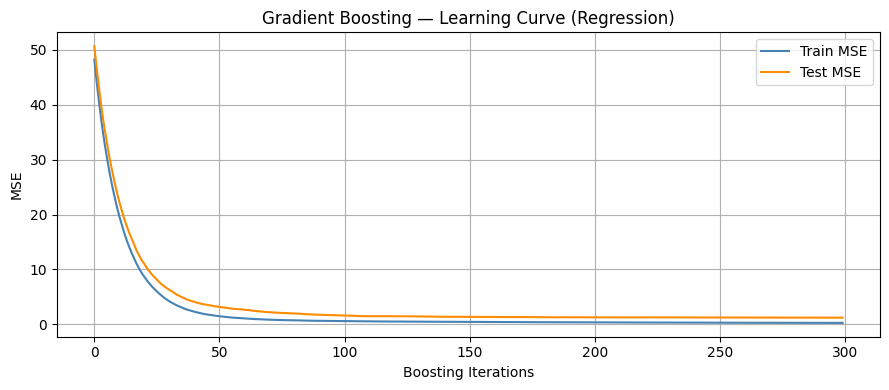

In [91]:
train_scores = [mean_squared_error(y_train, y_pred)
                for y_pred in gb_reg.staged_predict(X_train)]
test_scores  = [mean_squared_error(y_test,  y_pred)
                for y_pred in gb_reg.staged_predict(X_test)]

plt.figure(figsize=(9,4))
plt.plot(train_scores, label='Train MSE', color='steelblue')
plt.plot(test_scores,  label='Test MSE',  color='darkorange')
plt.xlabel('Boosting Iterations')
plt.ylabel('MSE')
plt.title('Gradient Boosting — Learning Curve (Regression)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### Gradient Boosting Classifier

In [92]:
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)
gb_clf.fit(X_train_class, Y_train_class)

gbc_train_acc = accuracy_score(Y_train_class, gb_clf.predict(X_train_class))
gbc_test_acc  = accuracy_score(Y_test_class,  gb_clf.predict(X_test_class))

print(f"Gradient Boosting Classifier")
print(f"  Train Accuracy : {gbc_train_acc:.4f}")
print(f"  Test  Accuracy : {gbc_test_acc:.4f}")
print()
print(classification_report(Y_test_class, gb_clf.predict(X_test_class),
                             target_names=['Low','Mid','High','Elite']))

Gradient Boosting Classifier
  Train Accuracy : 0.9384
  Test  Accuracy : 0.9033

              precision    recall  f1-score   support

         Low       0.92      0.94      0.93       175
         Mid       0.93      0.90      0.91       864
        High       0.88      0.89      0.88       942
       Elite       0.91      0.91      0.91      1887

    accuracy                           0.90      3868
   macro avg       0.91      0.91      0.91      3868
weighted avg       0.90      0.90      0.90      3868



## Ensembling — Method 4: Stacking

### Stacking Regressor

In [93]:
stacking_reg = StackingRegressor(
    estimators=[
        ('rf',  RandomForestRegressor(
            max_depth=12, max_features=None, min_samples_leaf=2,
            min_samples_split=8, n_estimators=100, random_state=42, n_jobs=-1
        )),
        ('gbr', GradientBoostingRegressor(
            n_estimators=150, learning_rate=0.05,
            max_depth=4, subsample=0.8, random_state=42
        )),
        ('svr', best_svr)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

stacking_reg.fit(X_train, y_train)

sr_train_rmse = np.sqrt(mean_squared_error(y_train, stacking_reg.predict(X_train)))
sr_test_rmse  = np.sqrt(mean_squared_error(y_test,  stacking_reg.predict(X_test)))
sr_train_r2   = r2_score(y_train, stacking_reg.predict(X_train))
sr_test_r2    = r2_score(y_test,  stacking_reg.predict(X_test))

print(f"Stacking Regressor")
print(f"  Train RMSE : {sr_train_rmse:.4f}  |  Test RMSE : {sr_test_rmse:.4f}")
print(f"  Train R²   : {sr_train_r2:.4f}  |  Test R²   : {sr_test_r2:.4f}")

Stacking Regressor
  Train RMSE : 0.5623  |  Test RMSE : 1.1368
  Train R²   : 0.9940  |  Test R²   : 0.9766


### Stacking Classifier

In [94]:
stacking_clf = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(
            criterion='gini', max_depth=8, class_weight='balanced',
            n_estimators=100, random_state=42, n_jobs=-1
        )),
        ('gbc', GradientBoostingClassifier(
            n_estimators=150, learning_rate=0.05,
            max_depth=4, subsample=0.8, random_state=42
        )),
        ('svc', best_svc)
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

stacking_clf.fit(X_train_class, Y_train_class)

sc_train_acc = accuracy_score(Y_train_class, stacking_clf.predict(X_train_class))
sc_test_acc  = accuracy_score(Y_test_class,  stacking_clf.predict(X_test_class))

print(f"Stacking Classifier")
print(f"  Train Accuracy : {sc_train_acc:.4f}")
print(f"  Test  Accuracy : {sc_test_acc:.4f}")
print()
print(classification_report(Y_test_class, stacking_clf.predict(X_test_class),target_names=['Low','Mid','High','Elite']))

Stacking Classifier
  Train Accuracy : 0.9242
  Test  Accuracy : 0.9085

              precision    recall  f1-score   support

         Low       0.92      0.96      0.94       175
         Mid       0.94      0.91      0.92       864
        High       0.87      0.89      0.88       942
       Elite       0.91      0.91      0.91      1887

    accuracy                           0.91      3868
   macro avg       0.91      0.92      0.91      3868
weighted avg       0.91      0.91      0.91      3868



## Unified Scouting Pipeline
A single function that accepts a raw player profile and simultaneously returns:
- **Predicted Market Value** (regression)
- **Predicted Performance Tier** (classification)

All preprocessing (continent mapping, position grouping, scaling, OHE) is applied internally.

In [128]:
def preprocess_player(raw_player: dict):

    p = pd.DataFrame([raw_player])

    p['Continent'] = p['Country'].map(country_to_continent).fillna('other')
    p['Position_Group'] = p['Position'].map(pos_to_group).fillna('other')

    raw_score = team_overall_train.get(raw_player.get('Team', ''), team_overall_train.median())
    p['team_tier'] = team_to_tier(raw_score)

    p['Age'] = p['Age'].clip(age_lower, age_upper)
    p['Future Potential'] = p['Future Potential'].clip(pot_lower, pot_upper)

    cols_num = ['Age', 'Total_Stats Score', 'Future Potential', 'team_tier', 'Overall_Rating']
    p[cols_num] = scaler.transform(p[cols_num])

    ohe_arr = ohe.transform(p[['Position_Group', 'Continent']])
    ohe_df  = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(['Position_Group', 'Continent']), index=p.index)
    p = pd.concat([p, ohe_df], axis=1)
    p = p.drop(columns=['Country', 'Position', 'Team', 'Position_Group', 'Continent'], errors='ignore')

    X_reg = p.reindex(columns=X_train.columns, fill_value=0)
    X_clf = p.drop(columns=['Overall_Rating'], errors='ignore').reindex(columns=X_train_class.columns, fill_value=0)

    return X_reg, X_clf

def scout_player(raw_player: dict) -> dict:
    X_reg, X_clf = preprocess_player(raw_player)

    predicted_value = gb_reg.predict(X_reg)[0]
    predicted_tier  = stacking_clf.predict(X_clf)[0]

    print("  Scouting Report")
    for k, v in raw_player.items():
        print(f"  {k:<22}: {v}")
    print(f"  Predicted Market Value  : ${predicted_value:.4f} M")
    print(f"  Predicted Tier          : {predicted_tier}")

    return {"predicted_value_M$": predicted_value, "predicted_tier": predicted_tier}

### Test Player

In [129]:
sample_player = {
    'Country':          'France',
    'Position':         'CM',
    'Age':              24,
    'Overall_Rating':   82,
    'Future Potential': 88,
    'Team':             'Paris Saint-Germain',
    'Total_Stats Score': 2050
}

scout_result = scout_player(sample_player)

  Scouting Report
  Country               : France
  Position              : CM
  Age                   : 24
  Overall_Rating        : 82
  Future Potential      : 88
  Team                  : Paris Saint-Germain
  Total_Stats Score     : 2050
  Predicted Market Value  : $43.4271 M
  Predicted Tier          : Elite


## Stability Assessment — Cross-Validation

In [97]:
kfold  = KFold(n_splits=5, shuffle=True, random_state=42)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [119]:
# Regression stability
gb_cv_r2 = cross_val_score(
    GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, min_samples_leaf=5, random_state=42
    ),
    X_train, y_train, cv=kfold, scoring='r2', n_jobs=-1
)

voting_cv_r2 = cross_val_score(
    voting_reg, 
    X_train, y_train, cv=kfold, scoring='r2', n_jobs=-1
)


stacking_cv_r2 = cross_val_score(
    stacking_reg, 
    X_train, y_train, cv=kfold, scoring='r2', n_jobs=-1
)

print("Stacking Regressor — 5-Fold CV R²")
print(f"  Folds  : {[round(s,4) for s in stacking_cv_r2]}")
print(f"  Mean   : {stacking_cv_r2.mean():.4f}")
print(f"  Std    : {stacking_cv_r2.std():.4f}")

print("Voting Regressor — 5-Fold CV R²")
print(f"  Folds  : {[round(s,4) for s in voting_cv_r2]}")
print(f"  Mean   : {voting_cv_r2.mean():.4f}")
print(f"  Std    : {voting_cv_r2.std():.4f}")


print("Gradient Boosting Regressor — 5-Fold CV R²")
print(f"  Folds  : {[round(s,4) for s in gb_cv_r2]}")
print(f"  Mean   : {gb_cv_r2.mean():.4f}")
print(f"  Std    : {gb_cv_r2.std():.4f}")

Stacking Regressor — 5-Fold CV R²
  Folds  : [np.float64(0.9811), np.float64(0.9858), np.float64(0.9747), np.float64(0.9633), np.float64(0.9749)]
  Mean   : 0.9760
  Std    : 0.0076
Voting Regressor — 5-Fold CV R²
  Folds  : [np.float64(0.9839), np.float64(0.991), np.float64(0.9695), np.float64(0.9647), np.float64(0.9746)]
  Mean   : 0.9768
  Std    : 0.0095
Gradient Boosting Regressor — 5-Fold CV R²
  Folds  : [np.float64(0.978), np.float64(0.9873), np.float64(0.9822), np.float64(0.9697), np.float64(0.9567)]
  Mean   : 0.9748
  Std    : 0.0108


In [120]:
gb_clf_cv = cross_val_score(
    GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, min_samples_leaf=5, random_state=42
    ),
    X_train_class, Y_train_class, cv=skfold, scoring='accuracy', n_jobs=-1
)

voting_cv = cross_val_score(
    voting_clf,
    X_train_class, Y_train_class, cv=skfold, scoring='accuracy', n_jobs=-1
)

stacking_cv_acc = cross_val_score(
    stacking_clf, 
    X_train_class, Y_train_class, cv=skfold, scoring='accuracy', n_jobs=-1
)

print("Stacking Classifier — Stratified 5-Fold CV")
print(f"  Folds  : {[round(s,4) for s in stacking_cv_acc]}")
print(f"  Mean   : {stacking_cv_acc.mean():.4f}")
print(f"  Std    : {stacking_cv_acc.std():.4f}")

print("Gradient Boosting Classifier — Stratified 5-Fold CV")
print(f"  Folds  : {[round(s,4) for s in gb_clf_cv]}")
print(f"  Mean   : {gb_clf_cv.mean():.4f}")
print(f"  Std    : {gb_clf_cv.std():.4f}")

print()
print("Voting Classifier — Stratified 5-Fold CV")
print(f"  Folds  : {[round(s,4) for s in voting_cv]}")
print(f"  Mean   : {voting_cv.mean():.4f}")
print(f"  Std    : {voting_cv.std():.4f}")

Stacking Classifier — Stratified 5-Fold CV
  Folds  : [np.float64(0.9005), np.float64(0.9121), np.float64(0.9043), np.float64(0.915), np.float64(0.914)]
  Mean   : 0.9092
  Std    : 0.0057
Gradient Boosting Classifier — Stratified 5-Fold CV
  Folds  : [np.float64(0.8988), np.float64(0.9105), np.float64(0.9069), np.float64(0.9179), np.float64(0.913)]
  Mean   : 0.9094
  Std    : 0.0064

Voting Classifier — Stratified 5-Fold CV
  Folds  : [np.float64(0.8933), np.float64(0.9063), np.float64(0.8966), np.float64(0.9056), np.float64(0.9101)]
  Mean   : 0.9024
  Std    : 0.0063


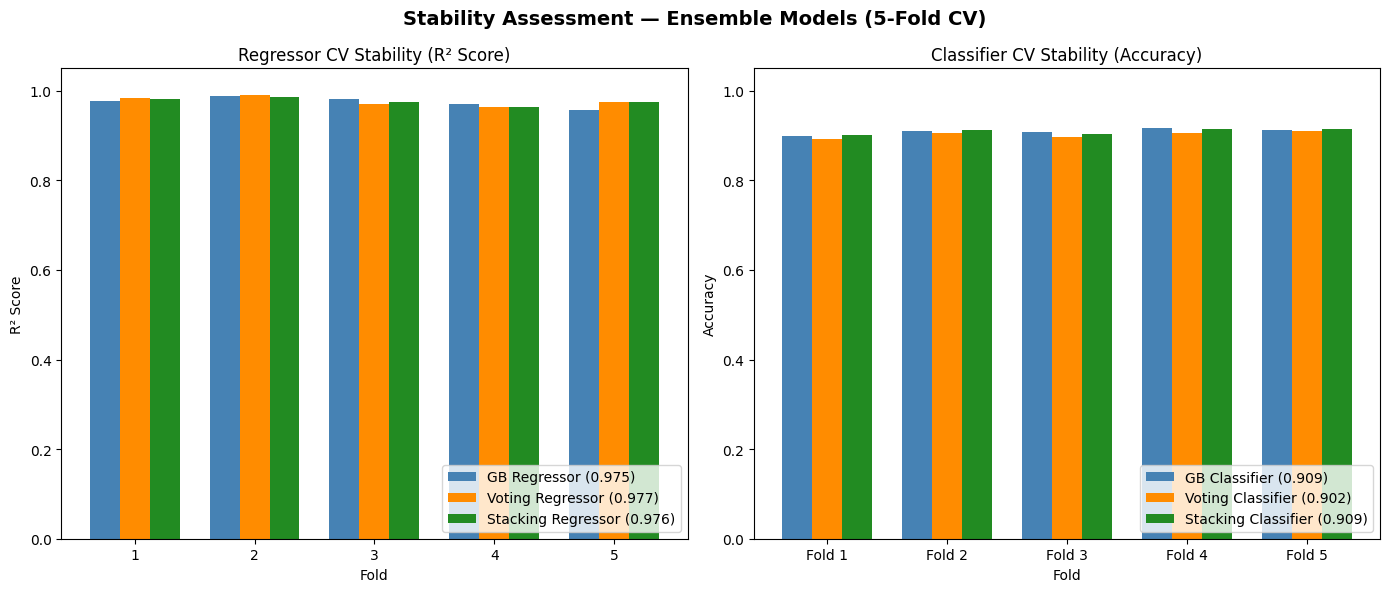

In [125]:
folds = np.arange(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bar_w = 0.25

axes[0].bar(folds - bar_w, gb_cv_r2, bar_w, label=f'GB Regressor ({gb_cv_r2.mean():.3f})', color='steelblue')
axes[0].bar(folds, voting_cv_r2, bar_w, label=f'Voting Regressor ({voting_cv_r2.mean():.3f})', color='darkorange')
axes[0].bar(folds + bar_w, stacking_cv_r2, bar_w, label=f'Stacking Regressor ({stacking_cv_r2.mean():.3f})', color='forestgreen')
axes[0].set_title('Regressor CV Stability (R² Score)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R² Score')
axes[0].set_xticks(folds)
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')


axes[1].bar(folds - bar_w, gb_clf_cv, bar_w, label=f'GB Classifier ({gb_clf_cv.mean():.3f})', color='steelblue')
axes[1].bar(folds, voting_cv, bar_w, label=f'Voting Classifier ({voting_cv.mean():.3f})', color='darkorange')
axes[1].bar(folds + bar_w, stacking_cv_acc, bar_w, label=f'Stacking Classifier ({stacking_cv_acc.mean():.3f})', color='forestgreen')
axes[1].set_title('Classifier CV Stability (Accuracy)')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(folds)
axes[1].set_xticklabels([f'Fold {i}' for i in folds])
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower right')

plt.suptitle('Stability Assessment — Ensemble Models (5-Fold CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [139]:

mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)

mlr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlr))
mlr_mae = mean_absolute_error(y_test, y_pred_mlr)
mlr_r2 = r2_score(y_test, y_pred_mlr)

y_pred_final_reg = stacking_reg.predict(X_test)

final_reg_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final_reg))
final_reg_mae = mean_absolute_error(y_test, y_pred_final_reg)
final_reg_r2 = r2_score(y_test, y_pred_final_reg)


y_pred_gnb = gnb.predict(X_test_class[num_features])
gnb_acc = accuracy_score(Y_test_class, y_pred_gnb) * 100
gnb_f1 = f1_score(Y_test_class, y_pred_gnb, average='macro', zero_division=0)
gnb_prec = precision_score(Y_test_class, y_pred_gnb, average='macro', zero_division=0)
gnb_rec = recall_score(Y_test_class, y_pred_gnb, average='macro', zero_division=0)


log_acc = accuracy_score(Y_test_class, Y_pred_class) * 100
log_f1 = f1_score(Y_test_class, Y_pred_class, average='macro', zero_division=0)
log_prec = precision_score(Y_test_class, Y_pred_class, average='macro', zero_division=0)
log_rec = recall_score(Y_test_class, Y_pred_class, average='macro', zero_division=0)


y_pred_final_clf = stacking_clf.predict(X_test_class)
final_clf_acc = accuracy_score(Y_test_class, y_pred_final_clf) * 100
final_clf_f1 = f1_score(Y_test_class, y_pred_final_clf, average='macro', zero_division=0)
final_clf_prec = precision_score(Y_test_class, y_pred_final_clf, average='macro', zero_division=0)
final_clf_rec = recall_score(Y_test_class, y_pred_final_clf, average='macro', zero_division=0)

In [142]:
print("Player Valuation")
print("| Metric     | Baseline 1 (Multi Linear) | Final Unified (Stacking) | Improvement vs Best Baseline |")
print("|:-----------|:--------------------------|:-------------------------|:-----------------------------|")
print(f"| RMSE       |         {mlr_rmse:.4f}            |         {final_reg_rmse:.4f}           |            {(mlr_rmse - final_reg_rmse):.4f}            |")
print(f"| MAE        |         {mlr_mae:.4f}            |         {final_reg_mae:.4f}           |            {(mlr_mae - final_reg_mae):.4f}            |")
print(f"| R² Score   |         {mlr_r2:.4f}            |         {final_reg_r2:.4f}           |            {(final_reg_r2 - mlr_r2):.4f}            |")

print("\n")

print("Performance Tier")
print("| Metric         | Baseline 1 (Naïve Bayes) | Baseline 2 (Logistic Reg.) | Final Unified (Stacking) | Improvement vs Best Baseline |")
print("|:---------------|:-------------------------|:---------------------------|:-------------------------|:-----------------------------|")
print(f"| Accuracy       |          {gnb_acc:.2f}%          |            {log_acc:.2f}%          |          {final_clf_acc:.2f}%          |              {(final_clf_acc - log_acc):.2f}%           |")
print(f"| Precision      |          {gnb_prec:.4f}          |           {log_prec:.4f}           |          {final_clf_prec:.4f}          |            {(final_clf_prec - log_prec):.4f}            |")
print(f"| Recall         |          {gnb_rec:.4f}          |           {log_rec:.4f}           |          {final_clf_rec:.4f}          |            {(final_clf_rec - log_rec):.4f}            |")
print(f"| Macro F1       |          {gnb_f1:.4f}          |           {log_f1:.4f}           |          {final_clf_f1:.4f}          |            {(final_clf_f1 - log_f1):.4f}            |")

Player Valuation
| Metric     | Baseline 1 (Multi Linear) | Final Unified (Stacking) | Improvement vs Best Baseline |
|:-----------|:--------------------------|:-------------------------|:-----------------------------|
| RMSE       |         5.8825            |         1.1368           |            4.7457            |
| MAE        |         2.9957            |         0.2407           |            2.7550            |
| R² Score   |         0.3744            |         0.9766           |            0.6023            |


Performance Tier
| Metric         | Baseline 1 (Naïve Bayes) | Baseline 2 (Logistic Reg.) | Final Unified (Stacking) | Improvement vs Best Baseline |
|:---------------|:-------------------------|:---------------------------|:-------------------------|:-----------------------------|
| Accuracy       |          76.84%          |            85.88%          |          90.85%          |              4.96%           |
| Precision      |          0.7741          |           0.86